# Computational Linear Algebra: PCA Homework

## Exercise 0.0: Initialization
Fill the missing values in this text box. **Remove the information of the second student if you are not working in a team**.

**Academic Year:** YYYY/YYYY

### Team Members (Alphabetical Order):
1. Surname1, Name1 (StudentID1);
2. Surname2, Name2 (StudentID2).

Now, fill the python list below with the Student IDs of the team

In [83]:
StudentIDs = [364189,360761]  # <-------- Fill this list with Student IDs of the team

## Exercise 0.1: Starting Code-Cell 

Download the .csv files from the web page of the course (*responses_hw.csv* and *columns_hw.csv*) and past them in **the same folder of this notebook**.


Then, run the cell below, **without modifing any line of code**.

The output of this code cell is **your personal subset of the original dataset**, with 2/3 of the original features (i.e., columns) and 3/4 of the original persons (i.e., rows).

### ATTENTION: DO NOT CHANGE THE CODE INSIDE THE FOLLOWING CELL, ANY CHANGE CAN INVALIDATE THE HOMEWORK!

In [84]:
####################################################################
############## DO NOT CHANGE THE CODE IN THIS CELL #################
####################################################################

import numpy as np
import pandas as pd
from IPython.display import display

var_entertainment_feat_types = ['Interests', 'Movies', 'Music']
var_personal_feat_types = ['Finance', 'Phobias']
fixed_feat_types = ['Personality', 'Health']

label_types = ['Demographic']

variables_by_type = {
    'Demographics': ['Age', 'Height', 'Weight', 'Number of siblings', 
                     'Gender', 'Hand', 'Education', 'Only child', 'Home Town Type',
                     'Home Type'],
    'Finance': ['Finances', 'Shopping centres', 'Branded clothing', 
                'Entertainment spending', 'Spending on looks', 
                'Spending on gadgets', 'Spending on healthy eating'],
    'Health': ['Smoking', 'Alcohol', 'Healthy eating'],
    'Interests': ['History', 'Psychology', 'Politics', 'Mathematics', 
                  'Physics', 'Internet', 'PC', 'Economy Management', 
                  'Biology', 'Chemistry', 'Reading', 'Geography', 
                  'Foreign languages', 'Medicine', 'Law', 'Cars', 
                  'Art exhibitions', 'Religion', 'Countryside, outdoors', 
                  'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 
                  'Active sport', 'Gardening', 'Celebrities', 'Shopping', 
                  'Science and technology', 'Theatre', 'Fun with friends', 
                  'Adrenaline sports', 'Pets'],
    'Movies': ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 
               'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 
               'Documentary', 'Western', 'Action'],
    'Music': ['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 
              'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 
              'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 
              'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 
              'Techno, Trance', 'Opera'],
    'Personality': ['Daily events', 'Prioritising workload', 
                    'Writing notes', 'Workaholism', 'Thinking ahead', 
                    'Final judgement', 'Reliability', 'Keeping promises', 
                    'Loss of interest', 'Friends versus money', 'Funniness', 
                    'Fake', 'Criminal damage', 'Decision making', 'Elections', 
                    'Self-criticism', 'Judgment calls', 'Hypochondria', 
                    'Empathy', 'Eating to survive', 'Giving', 
                    'Compassion to animals', 'Borrowed stuff', 
                    'Loneliness', 'Cheating in school', 'Health', 
                    'Changing the past', 'God', 'Dreams', 'Charity', 
                    'Number of friends', 'Punctuality', 'Lying', 'Waiting', 
                    'New environment', 'Mood swings', 'Appearence and gestures', 
                    'Socializing', 'Achievements', 'Responding to a serious letter', 
                    'Children', 'Assertiveness', 'Getting angry', 
                    'Knowing the right people', 'Public speaking', 
                    'Unpopularity', 'Life struggles', 'Happiness in life', 
                    'Energy levels', 'Small - big dogs', 'Personality', 
                    'Finding lost valuables', 'Getting up', 'Interests or hobbies', 
                    "Parents' advice", 'Questionnaires or polls', 'Internet usage'],
    'Phobias': ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 
                'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking']
}

labels = variables_by_type['Demographics']
features_all = []
for tt in variables_by_type.keys():
    if tt != 'Demographics':
        features_all += variables_by_type[tt]

def which_features(*StudentIDs):
    random_seed = min(StudentIDs)
    np.random.seed(random_seed)
    features_ = np.random.choice(features_all, int((2 * len(features_all)) / 3), replace=False).tolist()
    features = []
    features_by_type = {tt: [] for tt in variables_by_type.keys() if tt != 'Demographics'}
    for tt in variables_by_type.keys():
        ft_list = variables_by_type[tt]
        for ii in range(len(ft_list)):
            if ft_list[ii] in features_:
                features.append(ft_list[ii])
                features_by_type[tt].append(ft_list[ii])

    return features, features_by_type

features, features_by_type = which_features(*StudentIDs)

print(f'*** THESE ARE THE {len(features)} SELECTED FEATURES (SEE VARIABLE features):')
for ff in features:
    print(f'{ff}')
print('*************************************')
print('')
print('*** SELECTED FEATURES BY TYPES (SEE VARIABLE features_by_type):')
for tt in features_by_type.keys():
    print(f'{tt}: {features_by_type[tt]}')
    print('')
print('*************************************')
print('')
print('*** THESE ARE THE LABELS (SEE VARIABLE labels):')
for ll in labels:
    print(f'{ll}')
print('*************************************')

def which_rows(df, frac, *StudentIDs):
    random_seed = min(StudentIDs)
    df_ = df.sample(frac=frac, random_state=random_seed)
    return df_

responses_hw = pd.read_csv('responses_hw.csv', index_col=0)
responses = which_rows(responses_hw, 0.75, *StudentIDs)
responses = responses.loc[:, features + labels]

responses_ft = responses.loc[:, features]
responses_lb = responses.loc[:, labels]

print('')
print('*** THIS IS YOUR PERSONAL DATASET (features AND labels TOGETHER, SEE VARIABLE responses)')
display(responses)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)')
display(responses_ft)
print('')
print('*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)')
display(responses_lb)

random_seed = min(StudentIDs)
np.random.seed(random_seed)

your_scaler = np.random.choice(['StandardScaler', 'MinMaxScaler'])


*** THESE ARE THE 93 SELECTED FEATURES (SEE VARIABLE features):
Finances
Shopping centres
Branded clothing
Entertainment spending
Spending on looks
Spending on healthy eating
Smoking
Alcohol
History
Psychology
Physics
Internet
PC
Economy Management
Biology
Geography
Foreign languages
Medicine
Law
Cars
Art exhibitions
Countryside, outdoors
Writing
Passive sport
Gardening
Science and technology
Theatre
Adrenaline sports
Pets
Movies
Thriller
Romantic
Fantasy/Fairy tales
Animated
Western
Slow songs or fast songs
Dance
Folk
Country
Musical
Pop
Rock
Metal or Hardrock
Punk
Hiphop, Rap
Swing, Jazz
Latino
Techno, Trance
Opera
Prioritising workload
Writing notes
Workaholism
Thinking ahead
Final judgement
Keeping promises
Funniness
Fake
Criminal damage
Eating to survive
Giving
Compassion to animals
Borrowed stuff
Loneliness
Cheating in school
Changing the past
God
Dreams
Charity
Number of friends
Punctuality
Lying
New environment
Mood swings
Appearence and gestures
Socializing
Achievements
Respon

,Finances,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on healthy eating,Smoking,Alcohol,History,Psychology,...,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
649,3,3,2,2,2,4,tried smoking,social drinker,3,4,...,19,178,88,0,female,right,secondary school,yes,city,block of flats
605,4,4,2,5,2,3,tried smoking,drink a lot,4,2,...,22,174,83,1,male,right,college/bachelor degree,no,village,house/bungalow
9,2,2,1,3,1,2,tried smoking,never,2,2,...,17,176,60,1,female,right,primary school,no,city,block of flats
194,4,4,4,4,4,5,never smoked,social drinker,4,1,...,24,177,80,0,male,right,secondary school,yes,village,house/bungalow
514,3,4,3,3,3,3,never smoked,social drinker,2,2,...,20,197,100,1,male,right,college/bachelor degree,no,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,2,1,4,4,5,4,current smoker,social drinker,5,5,...,20,169,64,0,female,right,college/bachelor degree,yes,city,house/bungalow
394,3,4,2,2,3,2,tried smoking,social drinker,1,1,...,23,172,64,1,female,right,college/bachelor degree,no,city,block of flats
243,2,4,4,2,2,4,tried smoking,social drinker,5,2,...,18,160,50,2,female,right,primary school,no,city,block of flats
432,4,3,4,3,3,4,tried smoking,social drinker,2,3,...,19,163,50,1,female,right,secondary school,yes,city,block of flats



*** THIS IS YOUR PERSONAL DATASET (features, SEE VARIABLE responses_ft)


,Finances,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on healthy eating,Smoking,Alcohol,History,Psychology,...,Personality,Finding lost valuables,Getting up,Parents' advice,Internet usage,Storm,Heights,Snakes,Rats,Fear of public speaking
649,3,3,2,2,2,4,tried smoking,social drinker,3,4,...,3,4,3,4,less than an hour a day,4,3,5,1,3
605,4,4,2,5,2,3,tried smoking,drink a lot,4,2,...,3,3,4,3,few hours a day,2,2,5,3,2
9,2,2,1,3,1,2,tried smoking,never,2,2,...,3,3,5,4,few hours a day,1,3,5,5,5
194,4,4,4,4,4,5,never smoked,social drinker,4,1,...,4,2,4,3,less than an hour a day,3,1,4,2,4
514,3,4,3,3,3,3,never smoked,social drinker,2,2,...,4,1,2,3,few hours a day,2,2,5,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,2,1,4,4,5,4,current smoker,social drinker,5,5,...,4,4,2,3,few hours a day,4,5,5,1,3
394,3,4,2,2,3,2,tried smoking,social drinker,1,1,...,4,3,3,4,most of the day,5,3,5,4,3
243,2,4,4,2,2,4,tried smoking,social drinker,5,2,...,3,3,1,4,few hours a day,4,2,5,2,1
432,4,3,4,3,3,4,tried smoking,social drinker,2,3,...,3,3,4,3,few hours a day,3,3,5,5,1



*** THIS IS YOUR PERSONAL DATASET (labels, SEE VARIABLE responses_lb)


,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
649,19,178,88,0,female,right,secondary school,yes,city,block of flats
605,22,174,83,1,male,right,college/bachelor degree,no,village,house/bungalow
9,17,176,60,1,female,right,primary school,no,city,block of flats
194,24,177,80,0,male,right,secondary school,yes,village,house/bungalow
514,20,197,100,1,male,right,college/bachelor degree,no,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...
220,20,169,64,0,female,right,college/bachelor degree,yes,city,house/bungalow
394,23,172,64,1,female,right,college/bachelor degree,no,city,block of flats
243,18,160,50,2,female,right,primary school,no,city,block of flats
432,19,163,50,1,female,right,secondary school,yes,city,block of flats


## Exercise 0.2: Importing Modules

In the following cell, import all the modules you think are necessary for doing the homework, **among the ones listed and used during the laboratories of the course**.

For reproducibility, **no extra modules are allowed**.

**DO NOT IMPORT NUMPY NOR PANDAS**, they are already imported.

In [85]:
# DO NOT IMPORT NUMPY AND PANDAS - Already imported
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from matplotlib.lines import Line2D

## Exercise 1. Dataset Preprocessing

In this exercise, you have to do the following operations on the dataset of the features **responses_ft**:
1. Create a new dataframe called **responses_ft_enc** by encoding the categorical features (if they exist), motivating your choices;
1. Create a new dataframe called **responses_ft_pp** by preprocessing the data in **responses_ft_enc**, according to the scaler reported in the cell below.

In [86]:
print(f'*** YOU HAVE TO APPLY A PREPROCESSING USING THE {StandardScaler}')
# Copy the original feature dataset
responses_ft_enc = responses_ft.copy()

# Ordinal encoding for categorical features
encoding_maps = {
    'Smoking': { 
        'never smoked': 1,
        'tried smoking': 2,
        'former smoker': 3,
        'current smoker': 4
    },

    'Alcohol': { 
        'never': 1,
        'social drinker': 2,
        'drink a lot': 3
    },

    'Punctuality': {
        'early': 1,
        'on time': 2,
        'late': 3
    },

    'Lying': {
        'never': 1,
        'only to avoid hurting someone': 2,
        'sometimes': 3,
        'everytime it suits me': 4
    },

    'Internet usage': { 
        'no time at all': 1,
        'less than an hour a day': 2,
        'few hours a day': 3,
        'most of the day': 4
    }
}

# Encode only categorical columns that are present in our personal dataset
for column, mapping in encoding_maps.items():
    if column in responses_ft_enc.columns:
        responses_ft_enc[column] = responses_ft_enc[column].map(mapping)
        
print("*** ENCODED DATASET ***")
display(responses_ft_enc)

scaler = StandardScaler()
 
responses_ft_pp = pd.DataFrame(
    scaler.fit_transform(responses_ft_enc),
    columns=responses_ft_enc.columns,
    index=responses_ft_enc.index
)

print(f"*** PREPROCESSED DATASET USING {StandardScaler} ***")
display(responses_ft_pp)

*** YOU HAVE TO APPLY A PREPROCESSING USING THE <class 'sklearn.preprocessing._data.StandardScaler'>
*** ENCODED DATASET ***


,Finances,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on healthy eating,Smoking,Alcohol,History,Psychology,...,Personality,Finding lost valuables,Getting up,Parents' advice,Internet usage,Storm,Heights,Snakes,Rats,Fear of public speaking
649,3,3,2,2,2,4,2,2,3,4,...,3,4,3,4,2,4,3,5,1,3
605,4,4,2,5,2,3,2,3,4,2,...,3,3,4,3,3,2,2,5,3,2
9,2,2,1,3,1,2,2,1,2,2,...,3,3,5,4,3,1,3,5,5,5
194,4,4,4,4,4,5,1,2,4,1,...,4,2,4,3,2,3,1,4,2,4
514,3,4,3,3,3,3,1,2,2,2,...,4,1,2,3,3,2,2,5,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,2,1,4,4,5,4,4,2,5,5,...,4,4,2,3,3,4,5,5,1,3
394,3,4,2,2,3,2,2,2,1,1,...,4,3,3,4,4,5,3,5,4,3
243,2,4,4,2,2,4,2,2,5,2,...,3,3,1,4,3,4,2,5,2,1
432,4,3,4,3,3,4,2,2,2,3,...,3,3,4,3,3,3,3,5,5,1


*** PREPROCESSED DATASET USING <class 'sklearn.preprocessing._data.StandardScaler'> ***


,Finances,Shopping centres,Branded clothing,Entertainment spending,Spending on looks,Spending on healthy eating,Smoking,Alcohol,History,Psychology,...,Personality,Finding lost valuables,Getting up,Parents' advice,Internet usage,Storm,Heights,Snakes,Rats,Fear of public speaking
649,-0.068758,-0.223694,-0.791876,-0.980518,-0.908146,0.462792,-0.307051,-0.193338,-0.201750,0.672119,...,-0.438701,0.935530,-0.450568,0.898984,-1.922333,1.743970,0.281864,1.319813,-1.012645,0.150774
605,0.801033,0.551574,-0.791876,1.550819,-0.908146,-0.489130,-0.307051,1.553610,0.602072,-0.951233,...,-0.438701,0.137253,0.309390,-0.285615,0.070906,0.030477,-0.489072,1.319813,0.422644,-0.669565
9,-0.938549,-0.998962,-1.549323,-0.136739,-1.752856,-1.441052,-0.307051,-1.940286,-1.005572,-0.951233,...,-0.438701,0.137253,1.069349,0.898984,0.070906,-0.826269,0.281864,1.319813,1.857934,1.791451
194,0.801033,0.551574,0.723017,0.707040,0.781273,1.414714,-1.315932,-0.193338,0.602072,-1.762910,...,1.146890,-0.661024,0.309390,-0.285615,-1.922333,0.887224,-1.260008,0.649306,-0.295000,0.971112
514,-0.068758,0.551574,-0.034429,-0.136739,-0.063437,-0.489130,-1.315932,-0.193338,-1.005572,-0.951233,...,1.146890,-1.459301,-1.210527,-0.285615,0.070906,0.030477,-0.489072,1.319813,0.422644,0.150774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,-0.938549,-1.774230,0.723017,0.707040,1.625982,0.462792,1.710712,-0.193338,1.405894,1.483796,...,1.146890,0.935530,-1.210527,-0.285615,0.070906,1.743970,1.823735,1.319813,-1.012645,0.150774
394,-0.068758,0.551574,-0.791876,-0.980518,-0.063437,-1.441052,-0.307051,-0.193338,-1.809394,-1.762910,...,1.146890,0.137253,-0.450568,0.898984,2.064144,2.600717,0.281864,1.319813,1.140289,0.150774
243,-0.938549,0.551574,0.723017,-0.980518,-0.908146,0.462792,-0.307051,-0.193338,1.405894,-0.951233,...,-0.438701,0.137253,-1.970485,0.898984,0.070906,1.743970,-0.489072,1.319813,-0.295000,-1.489904
432,0.801033,-0.223694,0.723017,-0.136739,-0.063437,0.462792,-0.307051,-0.193338,-1.005572,-0.139557,...,-0.438701,0.137253,0.309390,-0.285615,0.070906,0.887224,0.281864,1.319813,1.857934,-1.489904


For doing this exercise, fill the cells below following the instructions you read.

#### Describe and motivate the encoding operations you will apply (max 150 words):
...

#### Describe the preprocessing operation you will apply and comment the effects it may have on the data (max 150 words):
...

#### Write the code for performing the encoding and preprocessing operations of the exercise. Show the encoded data and the preprocessed data you obtain, plus any additional table/value that can be useful for commenting the results:

In [ ]:
'''
We identified five categorical features: Smoking, Punctuality, Alcohol, Lying, Internet usage.
We applied ordinal encoding by manually mapping their string values to integers.
This converts the categorical features into numerical values for PCA while keeping each feature in a single column.

StandardScaler standardizes each non-constant feature by subtracting its mean and dividing by its standard deviation, 
resulting in zero mean and unit variance. This ensures comparable feature variances before computing the covariance matrix, 
preventing differences in numerical scale from dominating the PCA results.

Whereas, MinMaxScaler linearly rescales each feature to the interval [0, 1], 
preserving the relative spacing of its values without equalizing feature variances. 
It is suitable when a bounded input range is desired, such as in certain image processing and neural network applications.

'''

'\nWe identified five categorical features: Smoking, Punctuality, Alcohol, Lying, Internet usage.\nWe applied ordinal encoding by manually mapping their string values to integers.\nThis converts the categorical features into numerical values for PCA while keeping each feature in a single column.\n\n\n\n\n\n\n\n'

#### Comment the results obtained after the preprocessing operation (max 100 words):
...

## Exercise 2. Analyzing the Variance and the PCs

In this exercise, you have to do the following operations:
1. compute and visualize the variance of all the features in *responses_ft_enc* and *responses_ft_pp*;
1. compute all the $n$ Principal Components (PCs) for *responses_ft_enc* and *responses_ft_pp*, separately, and visualize the curves of the cumulative explained variances.

For doing this exercise, fill the cells below following the instructions you read.

#### Write the code for computing and visualizing the variance of the features of the two datasets:

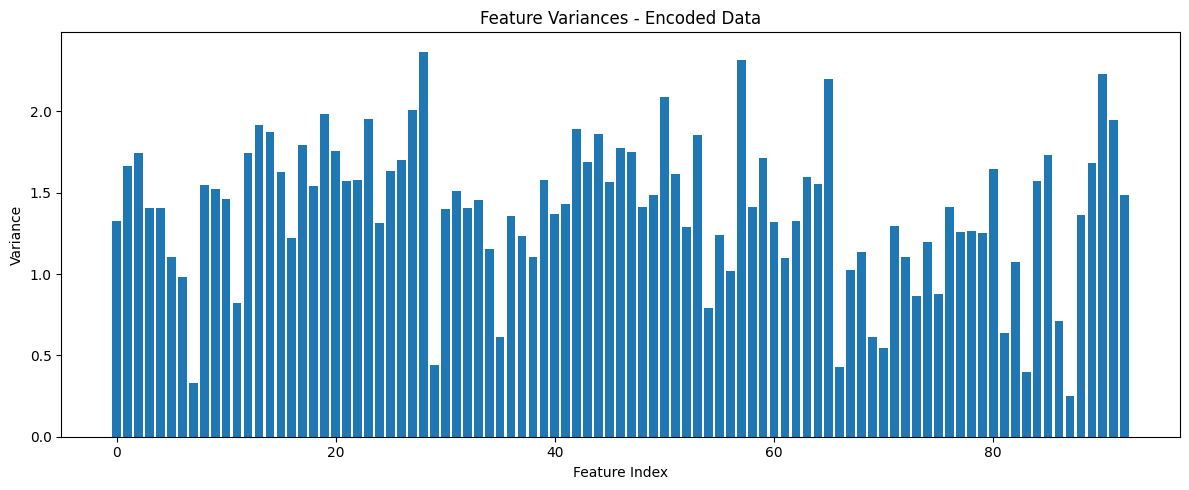

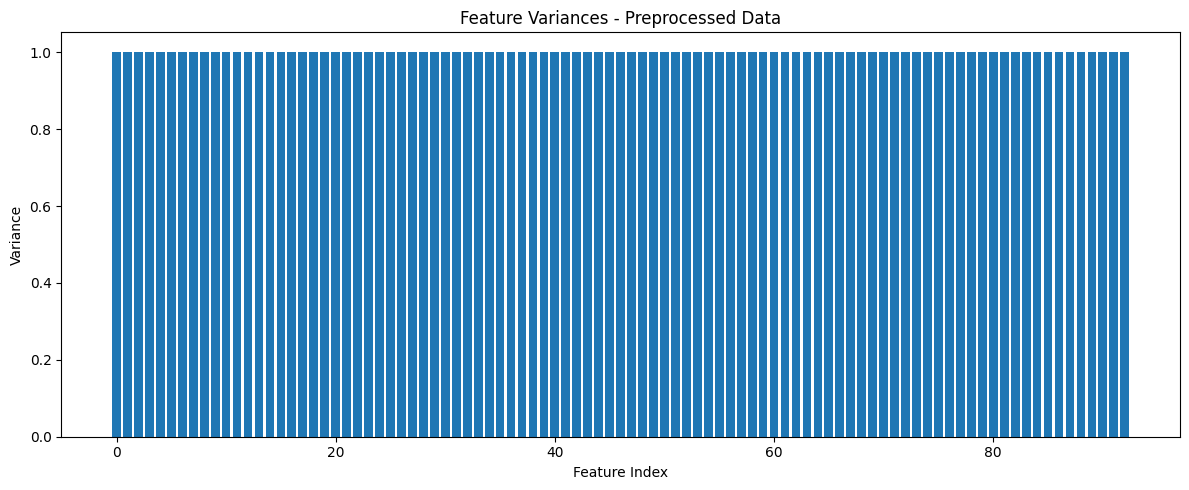

Mean variance - Encoded Data: 1.3965
Mean variance - Preprocessed Data: 1.0020


In [88]:
# [write the code here]
var_enc = responses_ft_enc.var()
var_pp = responses_ft_pp.var()

# Encoded data
plt.figure(figsize=(12, 5))
plt.bar(range(len(var_enc)), var_enc)

plt.title('Feature Variances - Encoded Data')
plt.xlabel('Feature Index')
plt.ylabel('Variance')

plt.tight_layout()
plt.show()

# Preprocessed data
plt.figure(figsize=(12, 5))
plt.bar(range(len(var_pp)), var_pp)

plt.title('Feature Variances - Preprocessed Data')
plt.xlabel('Feature Index')
plt.ylabel('Variance')

plt.tight_layout()
plt.show()

print(f"Mean variance - Encoded Data: {var_enc.mean():.4f}")
print(f"Mean variance - Preprocessed Data: {var_pp.mean():.4f}")

#### Comment the results obtained for the variances (max 150 words):
...

#### Write the code for computing all the $n$ PCs of the two datasets, separately, and for visualizing the curves of cumulative explained variances:

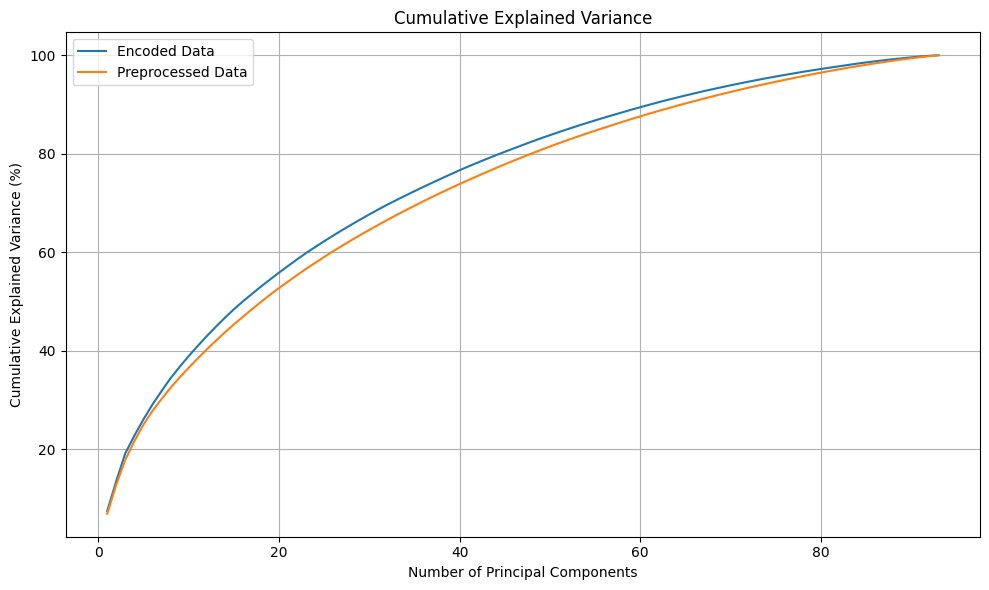

In [89]:
# [write the code here]
# PCA for encoded data
pca_enc = PCA()
pca_enc.fit(responses_ft_enc)    #learns pc directions, variances for components, eigval, eigvec

# PCA for preprocessed data
pca_pp = PCA()
pca_pp.fit(responses_ft_pp)

# Cumulative sum of each pca component (%)
cum_var_enc = np.cumsum(pca_enc.explained_variance_ratio_) * 100   
cum_var_pp = np.cumsum(pca_pp.explained_variance_ratio_) * 100

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cum_var_enc) + 1),
    cum_var_enc,
    label='Encoded Data'
)

plt.plot(
    range(1, len(cum_var_pp) + 1),
    cum_var_pp,
    label='Preprocessed Data'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Comment the results obtained for the cumulative explained variances, knowing the vaues in the datasets and the fetures' variances (max 150 words):

...

## Exercise 3. Dimensionality Reduction and PC Interpretation

In this exercise, you have to do the following operations:
1. For the dataset *responses_ft_pp*, compute a new PCA for performing a dimensionality reduction with respect to $m$ dimensions. The value of $m$ must be $$m = \min\{m', 5\}\,,$$ where $m'$ is the value required for obtaining $33\%$ of the total variance.
1. Visualize as a barplot the explained variance (as percentage) for each PC, and report the preserved explained variance (as percentage) by the $m$ PCs.
1. Visualize all the PCs as barplots and give an interpretation and a name to them, **motivating your choices**.
1. Transform the *responses_ft_pp* data into their $m$-dimensional representation via PCA. Store the transformed data in the variable *responses_ft_pca*;
1. Visualize the the score graph. If $m>3$, plot the score graph with respect to the first 3 PCs. All the **plots must show the names of the PCs (given at the previous step) on the axes** for better understanding the results.

#### Write the code for computing the new PCA, for visualizing the $m$ PCs as barplots:

Components needed for 33% variance (m'): 9
Components selected (m): 5


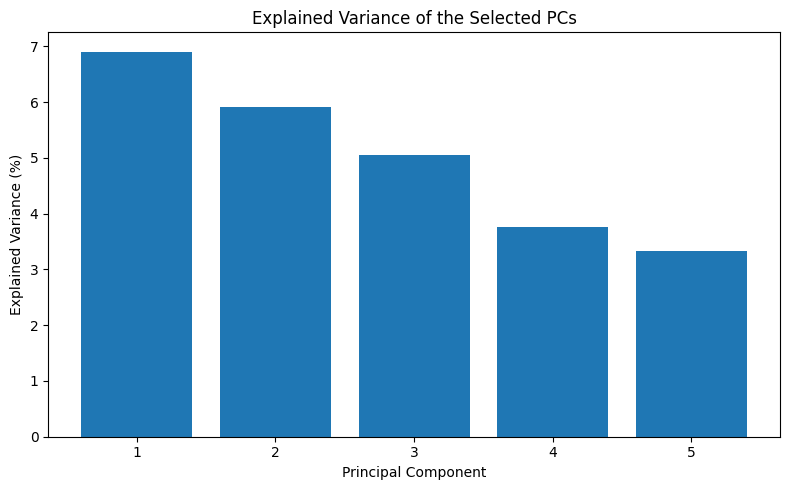

Preserved explained variance: 24.98%


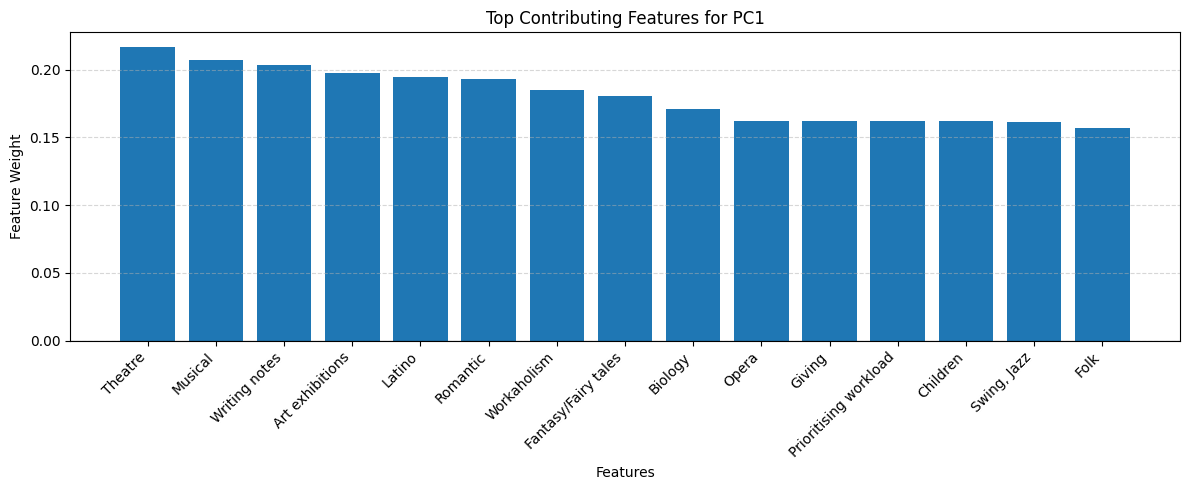

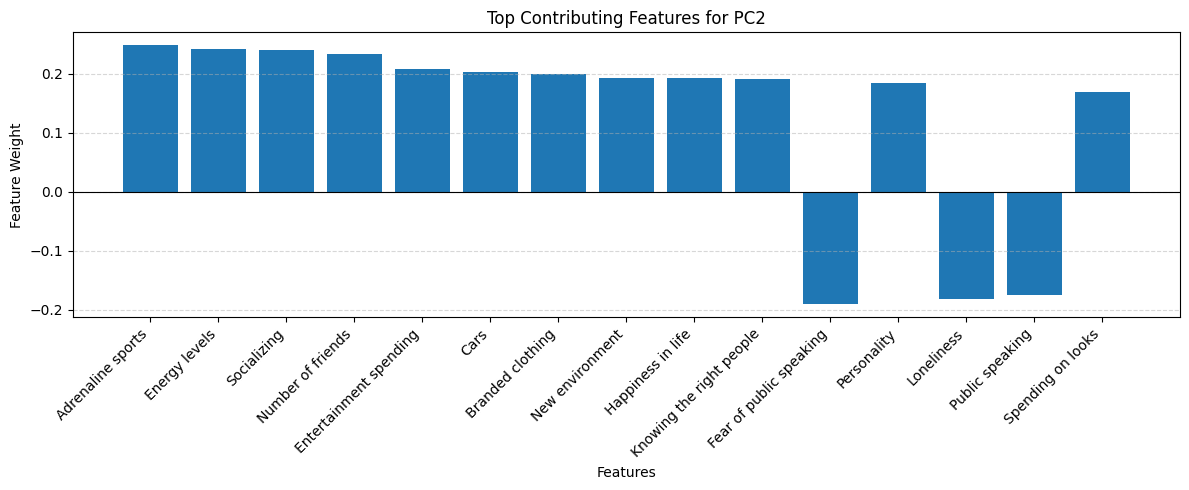

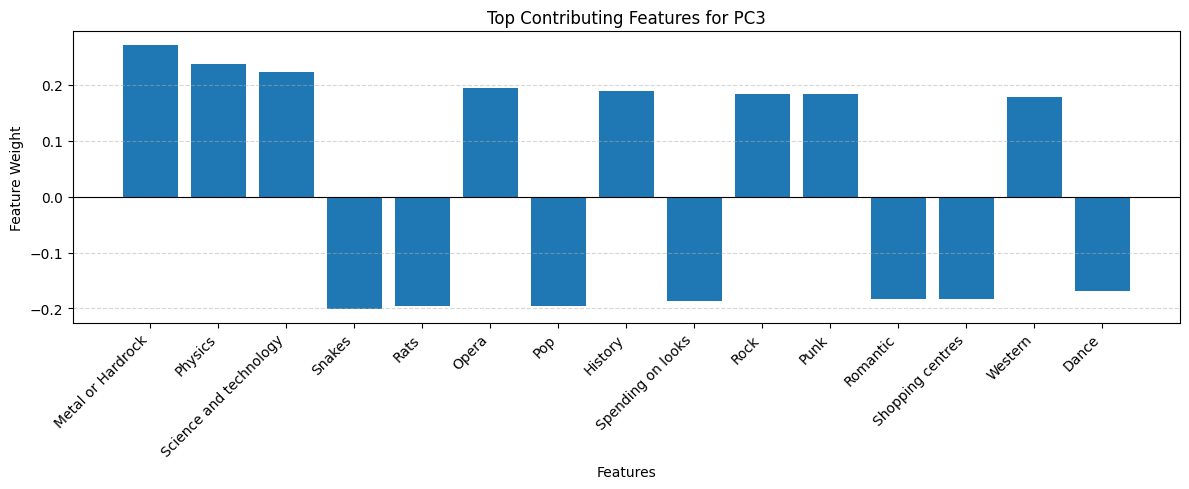

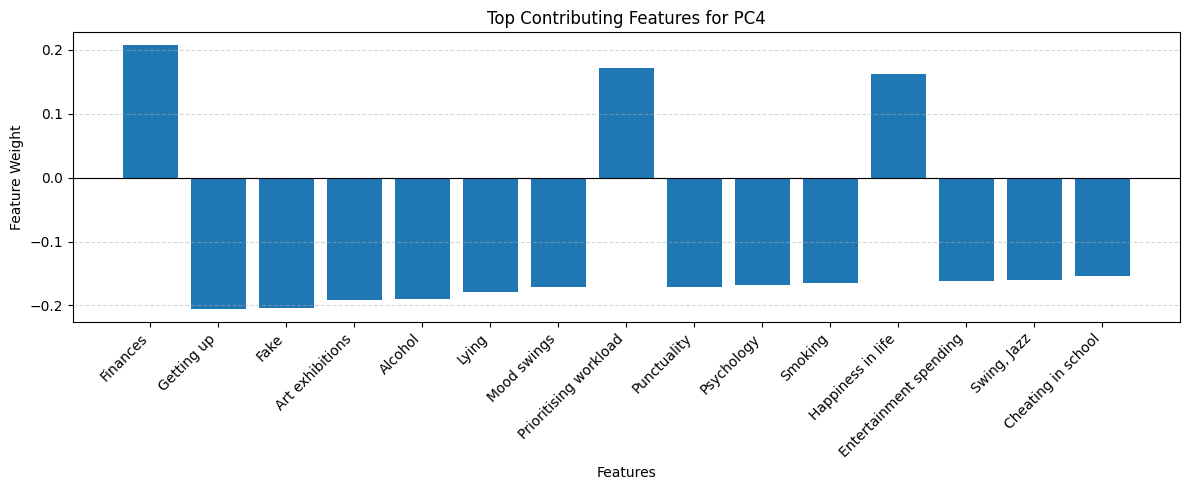

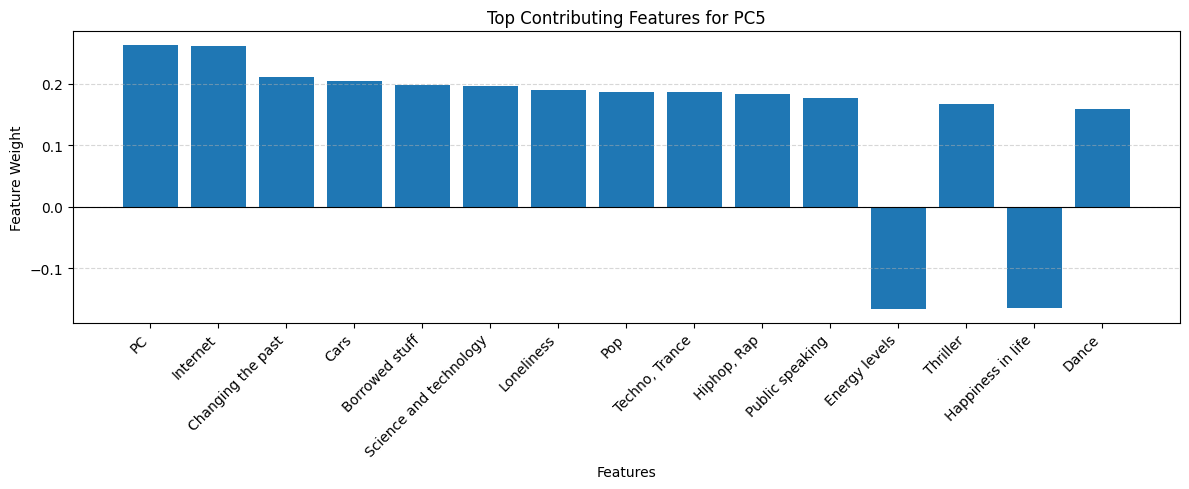

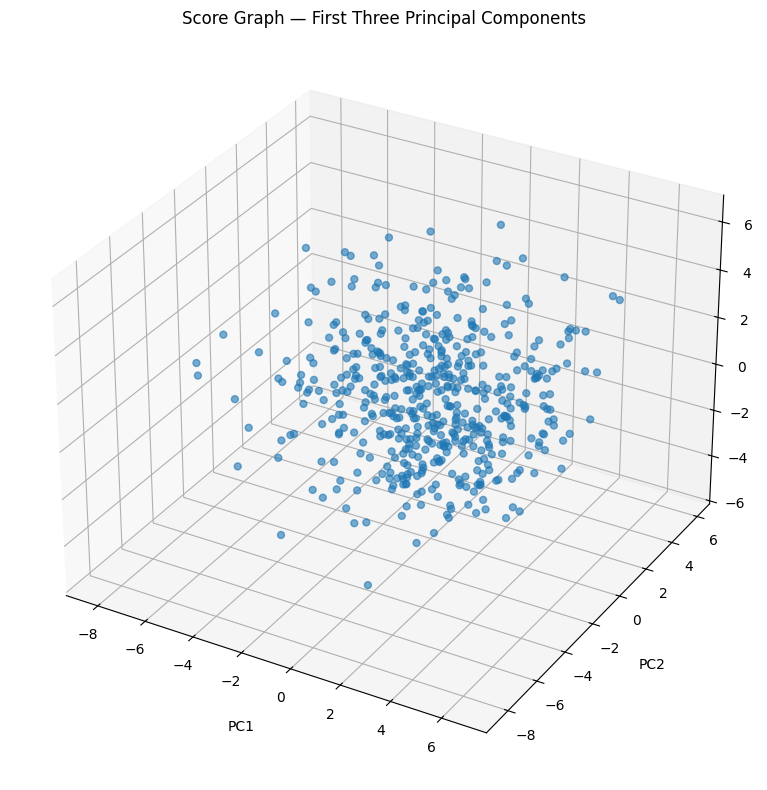

In [90]:
# 1. Calculate m (Number of Components)

# Cumulative explained variance from the previous PCA
cumulative_variance_ratio = np.cumsum(pca_pp.explained_variance_ratio_)

# Find the number of components needed to explain at least 33% of variance
m_prime = np.argmax(cumulative_variance_ratio >= 0.33) + 1 # +1 bc array stars from 0 

# use max 5 comp if m_prime is bigger than 5
m = min(m_prime, 5)

print(f"Components needed for 33% variance (m'): {m_prime}")
print(f"Components selected (m): {m}")

#********************************************************************************************************
# 2. Explained variance of the selected PCs

# Compute PCA with m components
pca_m = PCA(n_components=m)
pca_m.fit(responses_ft_pp)

# Explained variance percentage for each PC
explained_variance = pca_m.explained_variance_ratio_ * 100

# Total preserved variance
preserved_variance = np.sum(explained_variance)

# Barplot
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, m + 1),
    explained_variance
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance of the Selected PCs')

plt.xticks(range(1, m + 1))

plt.tight_layout()
plt.show()

print(f"Preserved explained variance: {preserved_variance:.2f}%")  # pc1 has most of the variance

#********************************************************************************************************
# 3. Visualize the top 15 contributing features for each PC

pc_names = [f'PC{i+1}' for i in range(m)]

components_df = pd.DataFrame(
    pca_m.components_,
    columns=responses_ft_pp.columns,
    index=pc_names
)

for pc in pc_names:
    # Select the 15 features with the largest absolute weights
    top_features = (
        components_df.loc[pc]
        .abs()
        .sort_values(ascending=False)
        .head(15)
        .index
    )

    # Preserve the original signs of the weights
    pc_weights = components_df.loc[pc, top_features]

    plt.figure(figsize=(12, 5))

    plt.bar(
        pc_weights.index,
        pc_weights.values,
    )

    plt.title(f'Top Contributing Features for {pc}')
    plt.xlabel('Features')
    plt.ylabel('Feature Weight')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()



# 4. Transform the data into the m-dimensional PCA representation

responses_ft_pca_array = pca_m.transform(responses_ft_pp)

pc_names = [f'PC{i+1}' for i in range(m)]

responses_ft_pca = pd.DataFrame(
    responses_ft_pca_array,
    index=responses_ft_pp.index,
    columns=pc_names
)

responses_ft_pca.head().style.set_caption("PCA Representation of the Preprocessed Data")

#********************************************************************************************************
# 5. Visualize the score graph using the first 3 PCs

pc_labels = [
    "PC1",
    "PC2",
    "PC3"
]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    responses_ft_pca.iloc[:, 0],
    responses_ft_pca.iloc[:, 1],
    responses_ft_pca.iloc[:, 2],
    s=25,
    alpha=0.6
)

ax.set_xlabel(pc_labels[0], labelpad=12)
ax.set_ylabel(pc_labels[1], labelpad=12)
ax.set_zlabel(pc_labels[2], labelpad=12)
ax.set_title('Score Graph — First Three Principal Components')

plt.tight_layout()
plt.show()






#### For each PC, write the name you assigned to it and a brief interpretation that motivate the choice (max 100 words per PC):

...

#### Write the code for visualizing the score graph (with PC names on the axis):

In [91]:
# [write the code here]

## Exercise 4. $k$-Means

In this exercise, you have to do the following operations:
1. Run the $k$-Means for clustering the data of *responses_ft_pca*, **setting the input argument *random_state* equal to the variable *random_seed*** (i.e., the minimum of the Student IDs).

   In particular, **use the silohuette score for identifying the best value for $k\in\{3, \ldots, 10\}$** and show it by plotting how the score changes w.r.t. $k$.
1. Plot the score graph again, but add the centroids of the cluster and color the points according to their cluster.
1. Visualize the centroids coordinates as barplots and **give a name and an interpretation to them by exploiting the PC names**.


#### Write the code for performing the items of the list above:

Best k: 9
Best silhouette score: 0.1666


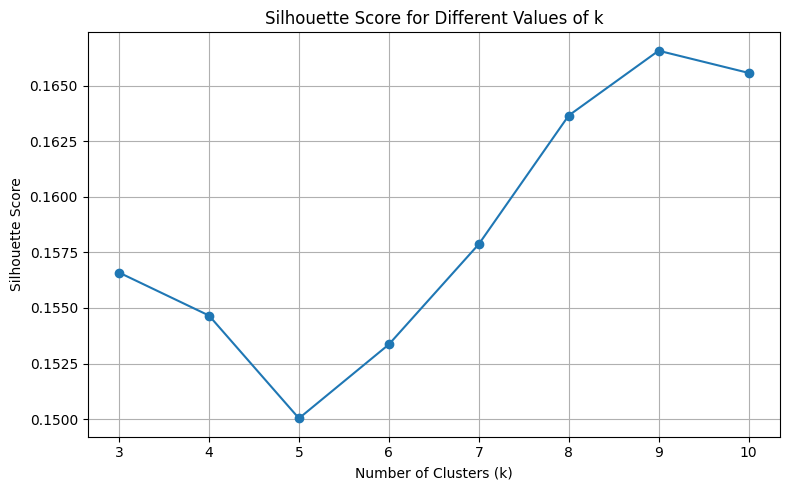

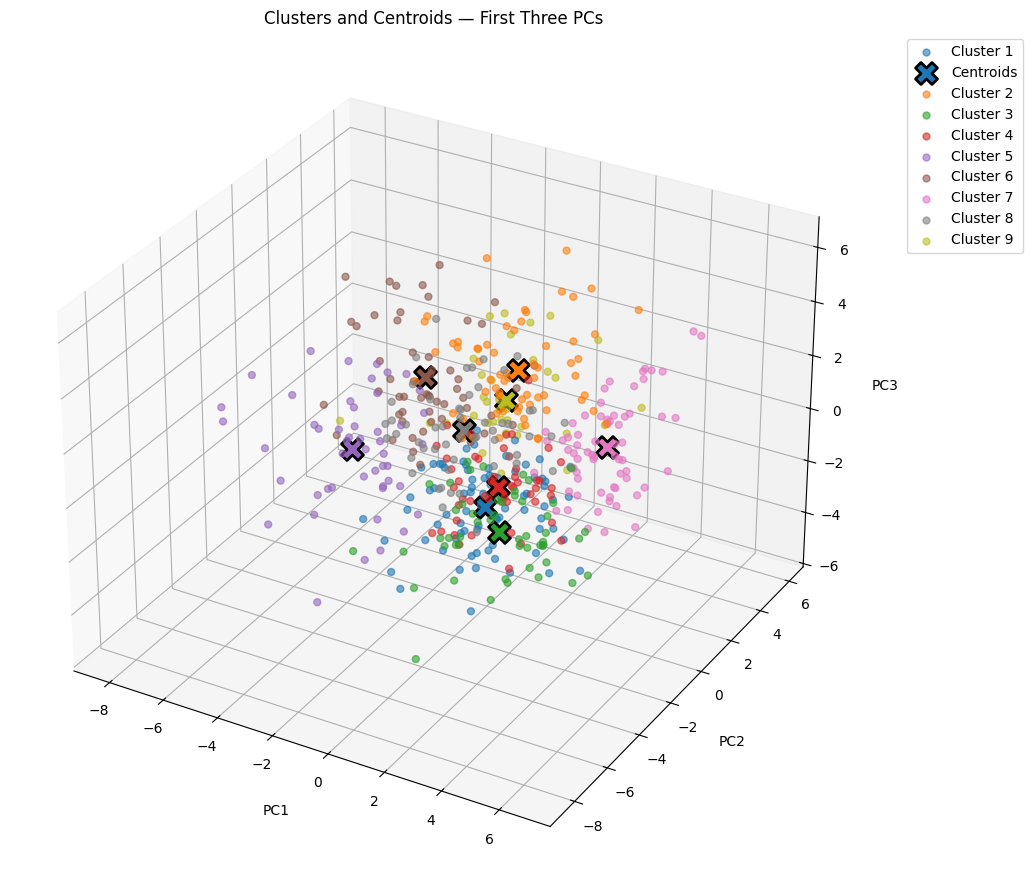

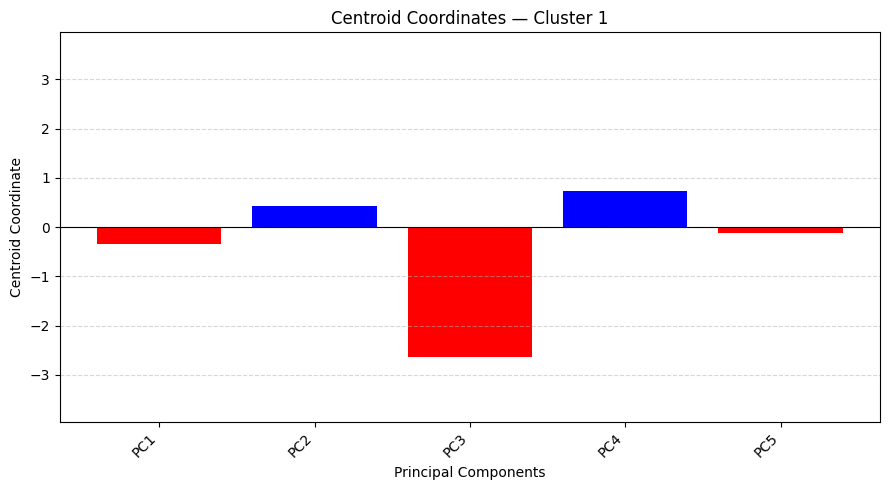

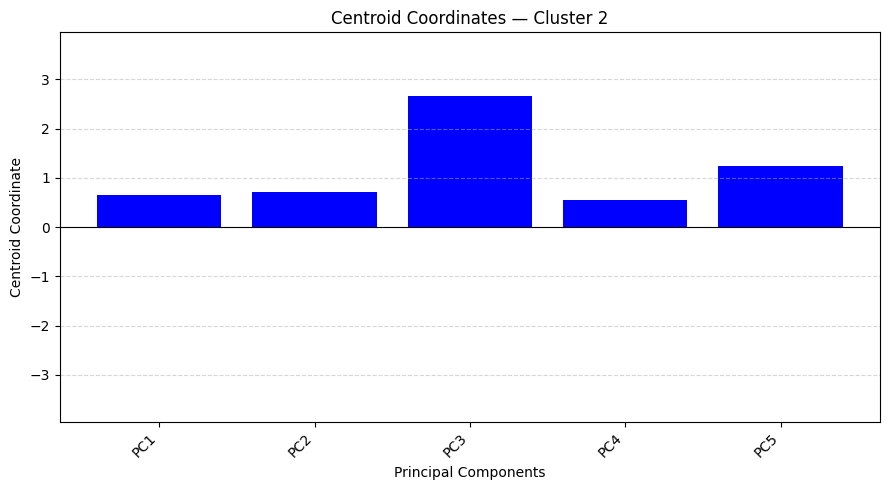

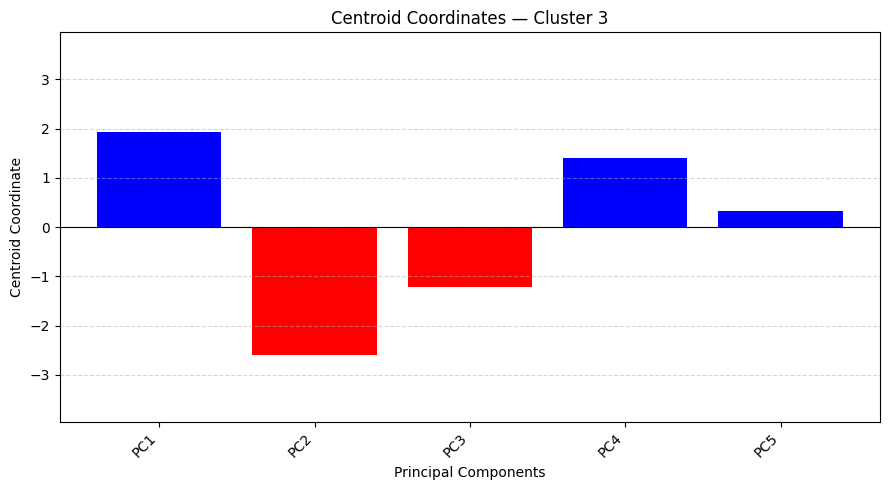

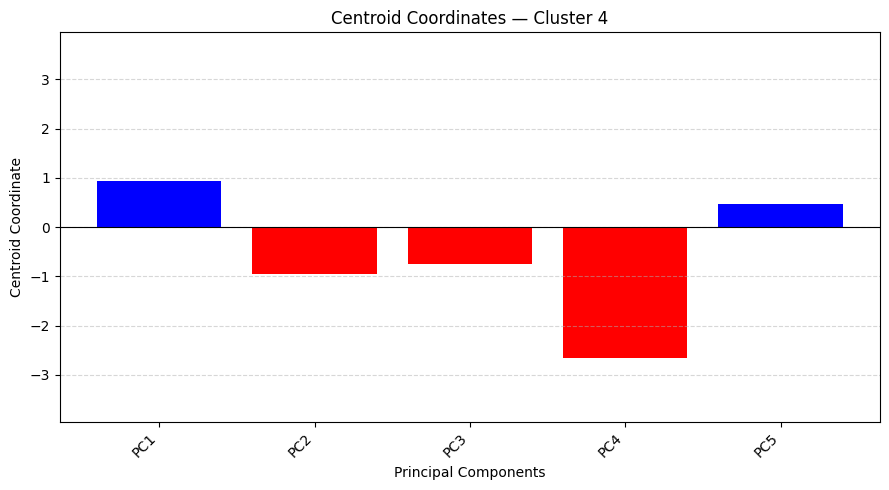

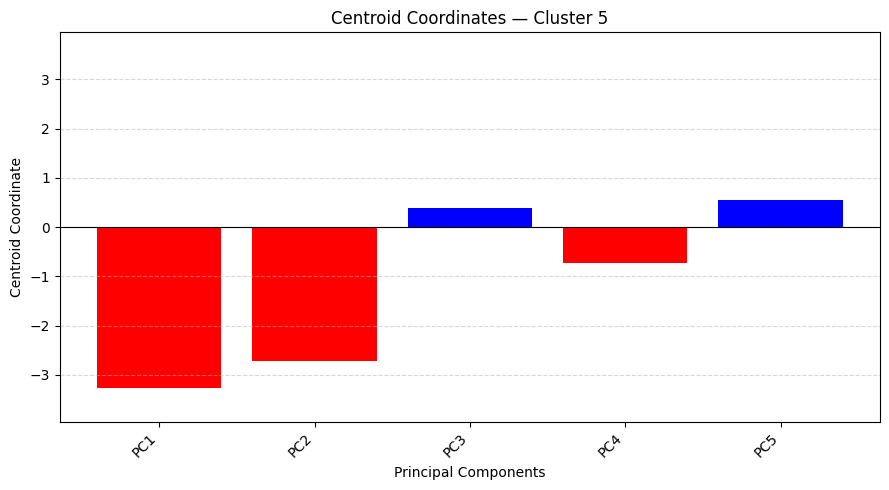

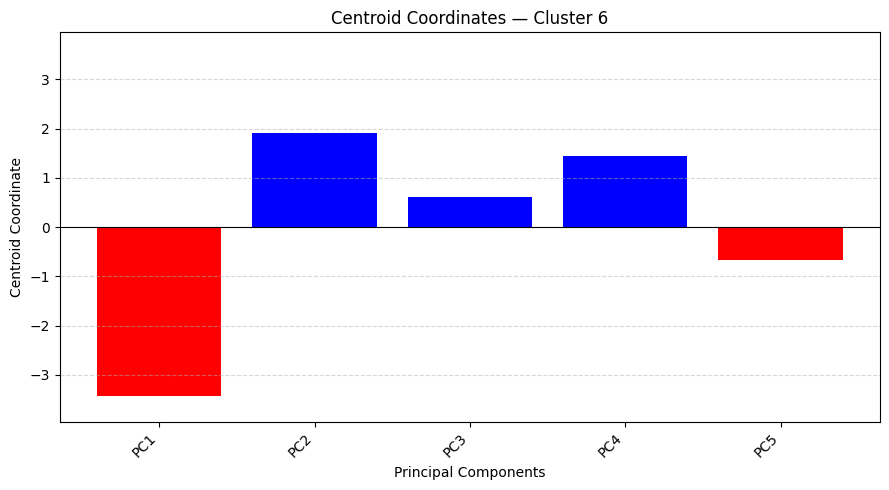

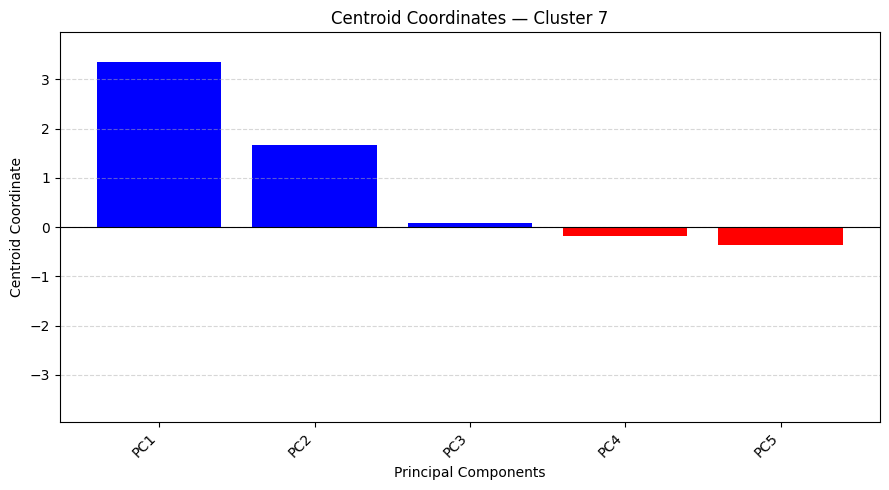

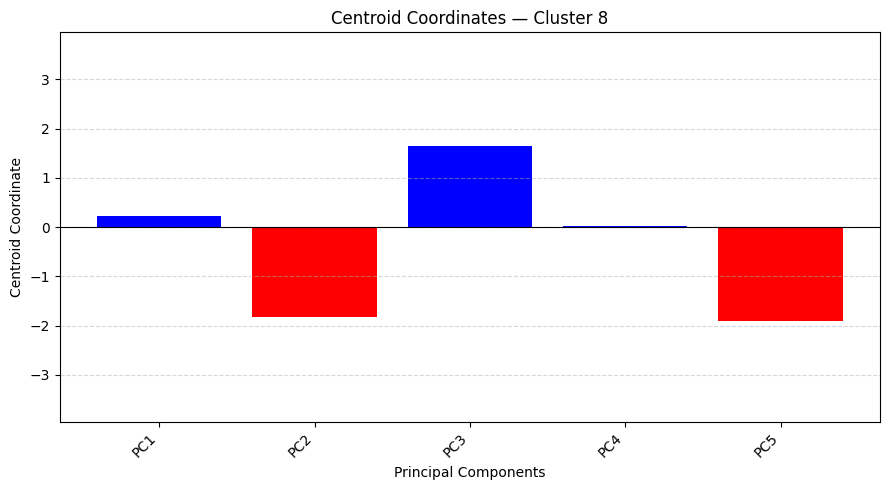

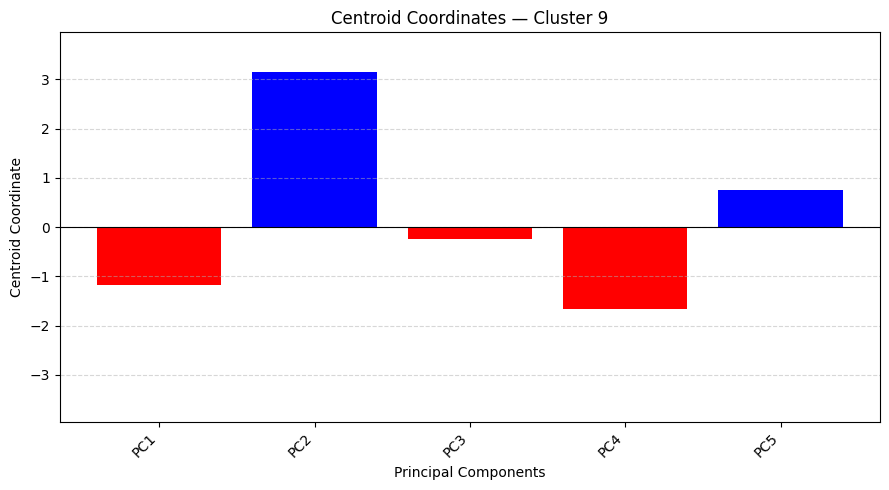

,PC1,PC2,PC3,PC4,PC5
Cluster 1,-0.335770,0.431707,-2.635424,0.727346,-0.120673
Cluster 2,0.644686,0.714984,2.660912,0.541977,1.229433
Cluster 3,1.921633,-2.590048,-1.210672,1.411129,0.319237
Cluster 4,0.925108,-0.951191,-0.749093,-2.669330,0.458947
Cluster 5,-3.272677,-2.728688,0.379841,-0.722530,0.557141
Cluster 6,-3.438585,1.901718,0.604095,1.437974,-0.673324
Cluster 7,3.345140,1.656409,0.081151,-0.190225,-0.365103
Cluster 8,0.217923,-1.817292,1.641876,0.022901,-1.911988
Cluster 9,-1.174801,3.150869,-0.246359,-1.666656,0.744518


In [92]:
# 4.1 Find the best k using the silhouette score

k_values = range(3, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=random_seed,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(responses_ft_pca)

    score = silhouette_score(
        responses_ft_pca,
        cluster_labels
    )

    silhouette_scores.append(score)


# Best value of k
best_k = list(k_values)[np.argmax(silhouette_scores)]

print(f"Best k: {best_k}")
print(f"Best silhouette score: {max(silhouette_scores):.4f}")


# Plot silhouette score for each k
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of k')

plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

#********************************************************************************************************
# 4.2. Plot the clusters and their centroids

# Fit K-Means using all selected PCs
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=random_seed,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(responses_ft_pca)
centroids = final_kmeans.cluster_centers_

# Visualize the first three PCs
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = plt.get_cmap('tab10')

for cluster in range(best_k):
    mask = cluster_labels == cluster

    ax.scatter(
        responses_ft_pca.iloc[mask, 0],
        responses_ft_pca.iloc[mask, 1],
        responses_ft_pca.iloc[mask, 2],
        color=colors(cluster),
        s=25,
        alpha=0.6,
        label=f'Cluster {cluster + 1}'
    )

    ax.scatter(
        centroids[cluster, 0],
        centroids[cluster, 1],
        centroids[cluster, 2],
        color=colors(cluster),
        marker='X',
        s=250,
        edgecolors='black',
        linewidths=2,
        label='Centroids' if cluster == 0 else None
    )

# Use the PC interpretation names defined in Exercise 3.5
ax.set_xlabel(pc_labels[0], labelpad=12)
ax.set_ylabel(pc_labels[1], labelpad=12)
ax.set_zlabel(pc_labels[2], labelpad=12)

ax.set_title('Clusters and Centroids — First Three PCs')
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

#********************************************************************************************************

# 4.3. Visualize centroid coordinates as barplots

# Replace these labels with your PC interpretation names
pc_interpretation_names = [
    'PC1',
    'PC2',
    'PC3',
    'PC4',
    'PC5'
][:responses_ft_pca.shape[1]]

centroids_df = pd.DataFrame(
    centroids,
    columns=pc_interpretation_names,
    index=[f'Cluster {i + 1}' for i in range(len(centroids))]
)

for cluster_name, coordinates in centroids_df.iterrows():
    plt.figure(figsize=(9, 5))

    plt.bar(
        coordinates.index,
        coordinates.values,
        color=np.where(coordinates >= 0, 'blue', 'red')
    )

    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f'Centroid Coordinates — {cluster_name}')
    plt.xlabel('Principal Components')
    plt.ylabel('Centroid Coordinate')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Use the same scale to compare clusters
    limit = np.abs(centroids).max()
    plt.ylim(-1.15 * limit, 1.15 * limit) if limit > 0 else None

    plt.tight_layout()
    plt.show()

display(centroids_df)



#### For each Centroid, write the name you assigned to it and a brief interpretation that motivate the choice by exploiting the PC names(max 100 words per centroid):

...

## Exercise 5. Cluster External Evaluations

In this exercise, you have to do the following operations:
1. Select a subset meaningful labels for performing an external evaluation of the clustering results.
1. For each selected label, visualize the distribution of the label in each cluster and in the whole dataset.
1. Visualize the score graph with dots colored with respect to the label value; then, visualize the clusters in separated score-graphs, coloring the points according to the label values.


#### List the Labels you consider meaningful for an external cluster evaluation and motivate your choice (max 50 words per label):

...


#### Write the code for the visualizations cited in item 2 above:

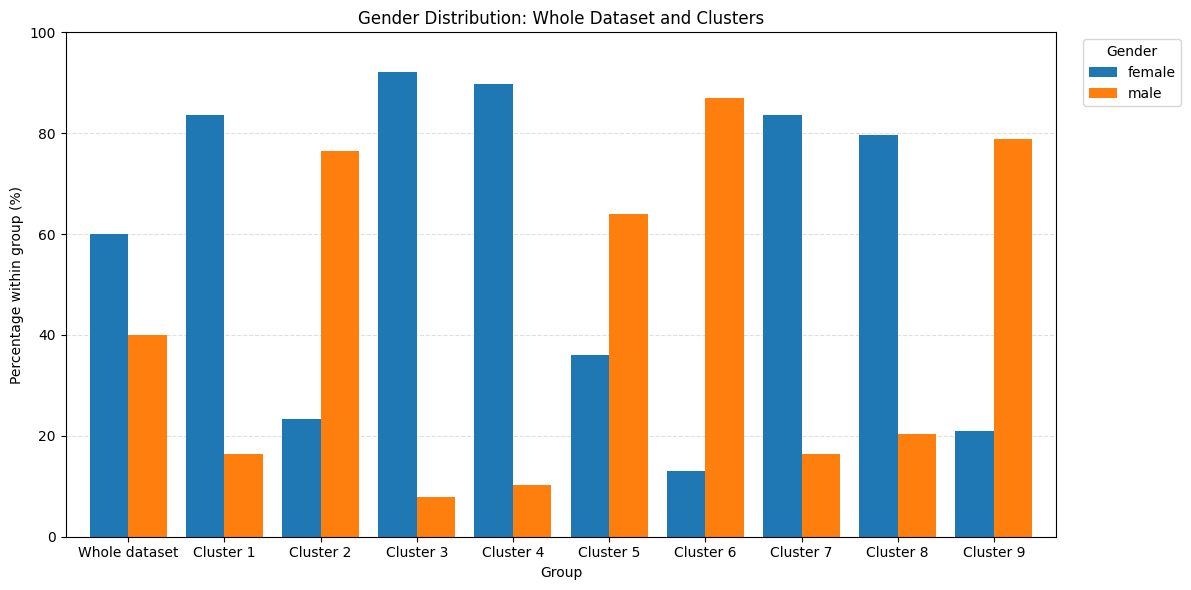

Gender,female,male
Whole dataset,60.08,39.92
Cluster 1,83.54,16.46
Cluster 2,23.44,76.56
Cluster 3,92.16,7.84
Cluster 4,89.80,10.20
Cluster 5,36.00,64.00
Cluster 6,12.96,87.04
Cluster 7,83.58,16.42
Cluster 8,79.63,20.37
Cluster 9,21.05,78.95


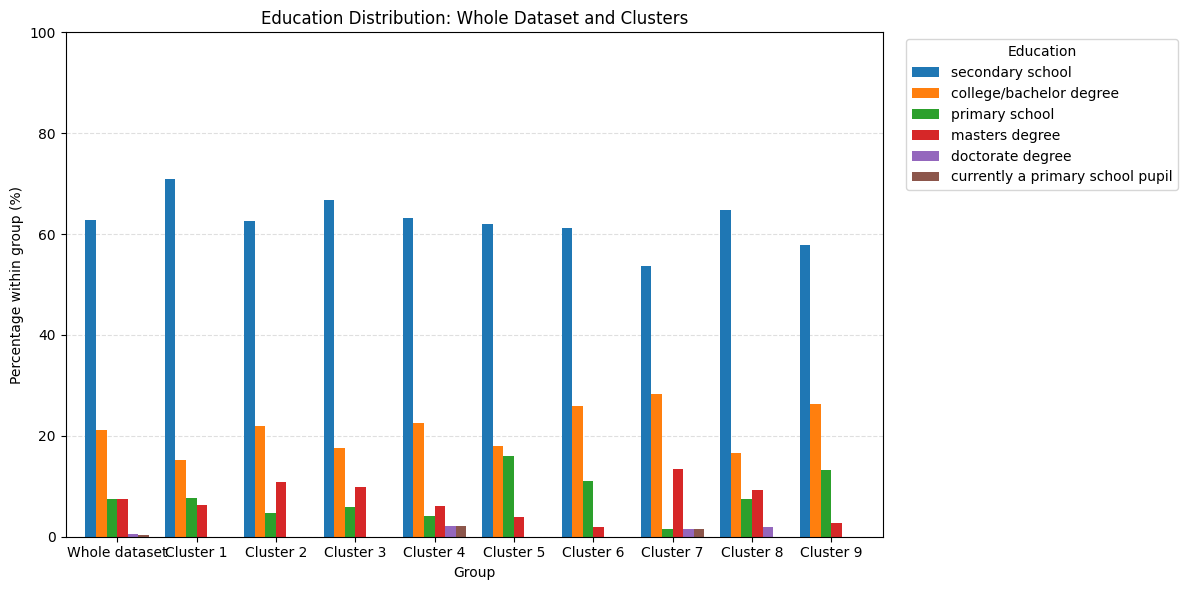

Education,secondary school,college/bachelor degree,primary school,masters degree,doctorate degree,currently a primary school pupil
Whole dataset,62.85,21.15,7.51,7.51,0.59,0.40
Cluster 1,70.89,15.19,7.59,6.33,0.00,0.00
Cluster 2,62.50,21.88,4.69,10.94,0.00,0.00
Cluster 3,66.67,17.65,5.88,9.80,0.00,0.00
Cluster 4,63.27,22.45,4.08,6.12,2.04,2.04
Cluster 5,62.00,18.00,16.00,4.00,0.00,0.00
Cluster 6,61.11,25.93,11.11,1.85,0.00,0.00
Cluster 7,53.73,28.36,1.49,13.43,1.49,1.49
Cluster 8,64.81,16.67,7.41,9.26,1.85,0.00
Cluster 9,57.89,26.32,13.16,2.63,0.00,0.00


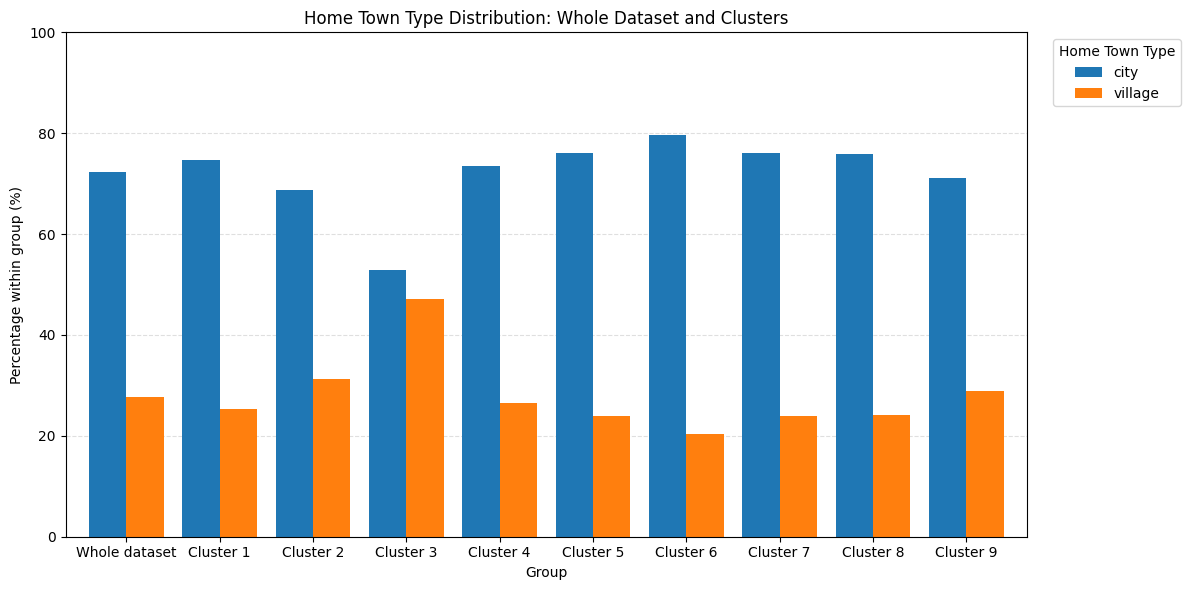

Home Town Type,city,village
Whole dataset,72.33,27.67
Cluster 1,74.68,25.32
Cluster 2,68.75,31.25
Cluster 3,52.94,47.06
Cluster 4,73.47,26.53
Cluster 5,76.00,24.00
Cluster 6,79.63,20.37
Cluster 7,76.12,23.88
Cluster 8,75.93,24.07
Cluster 9,71.05,28.95


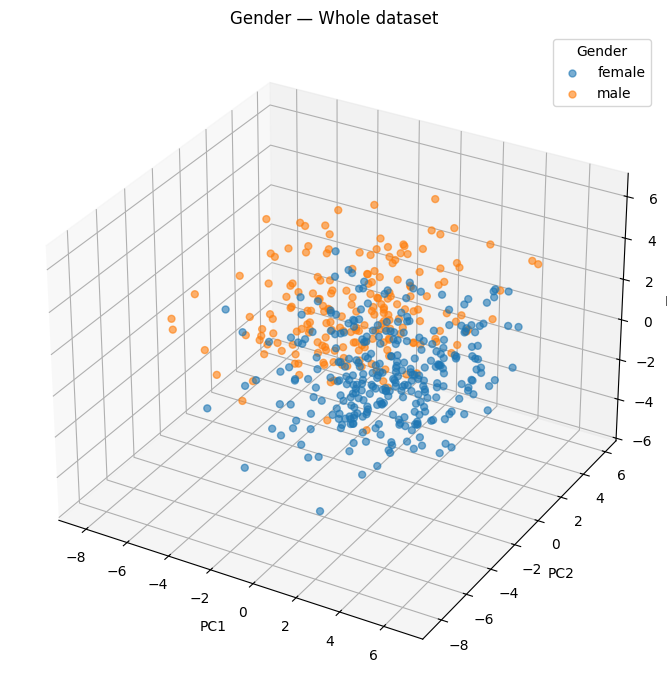

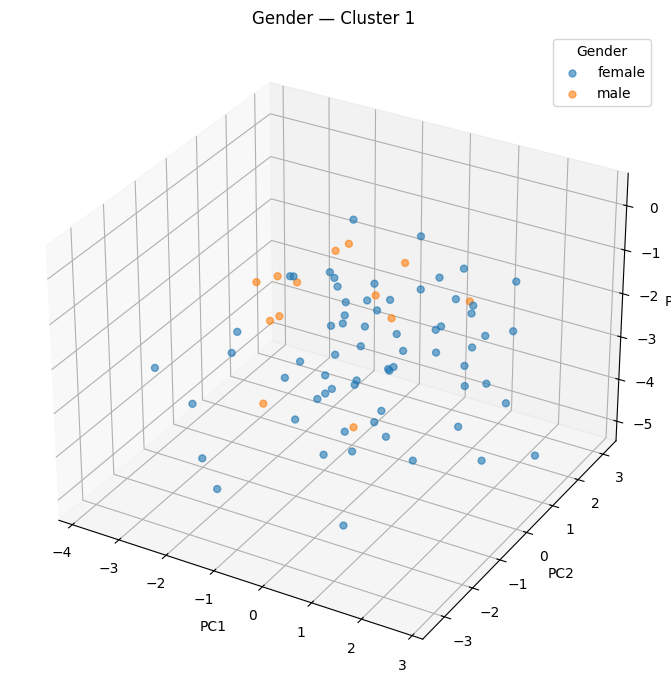

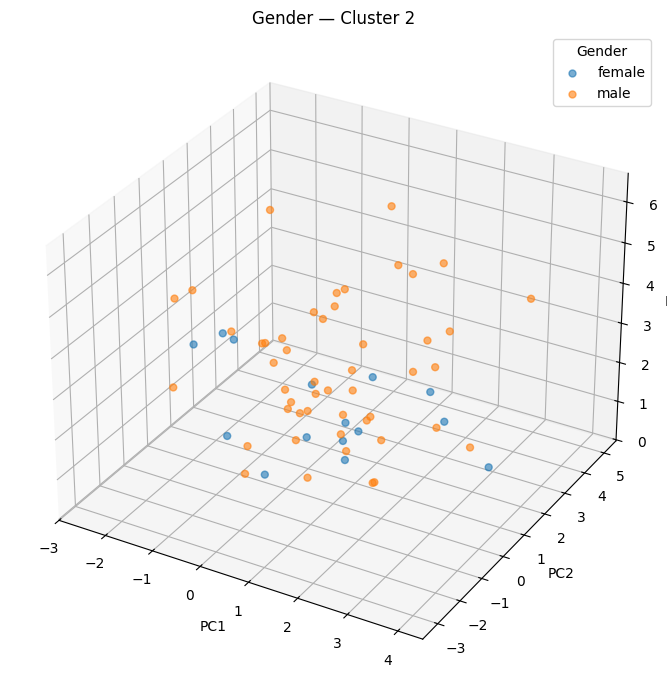

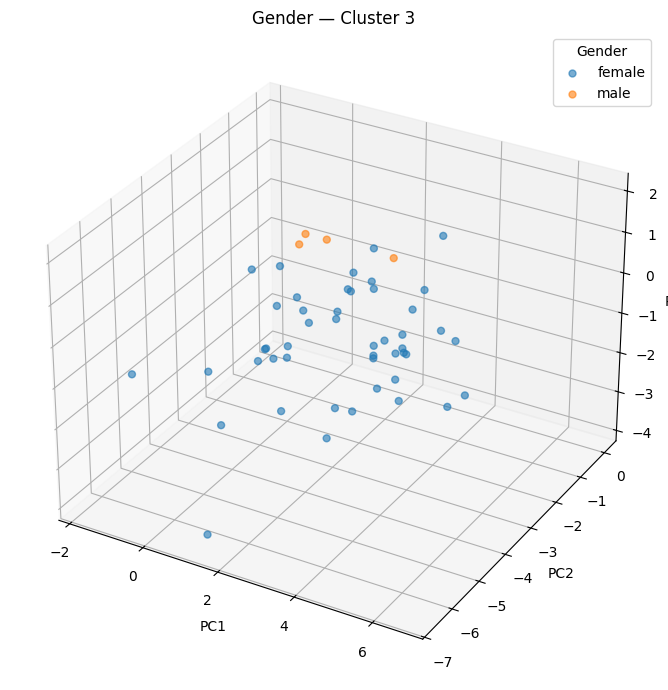

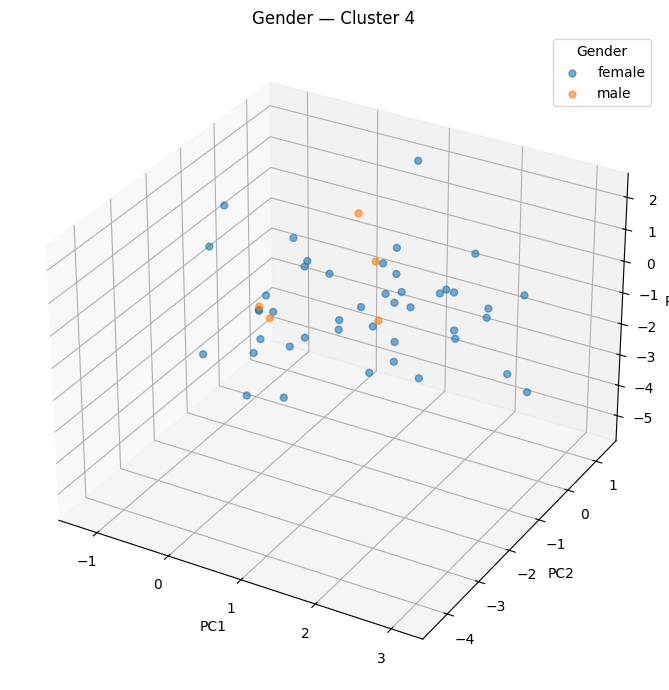

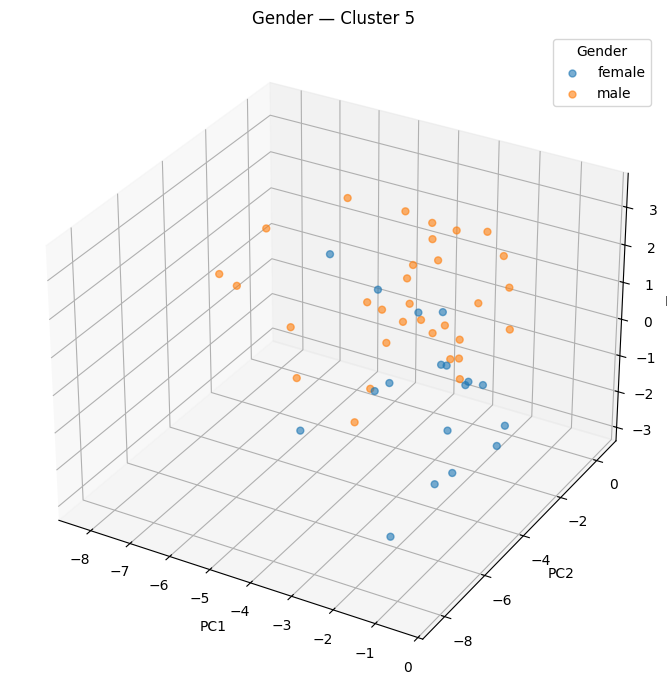

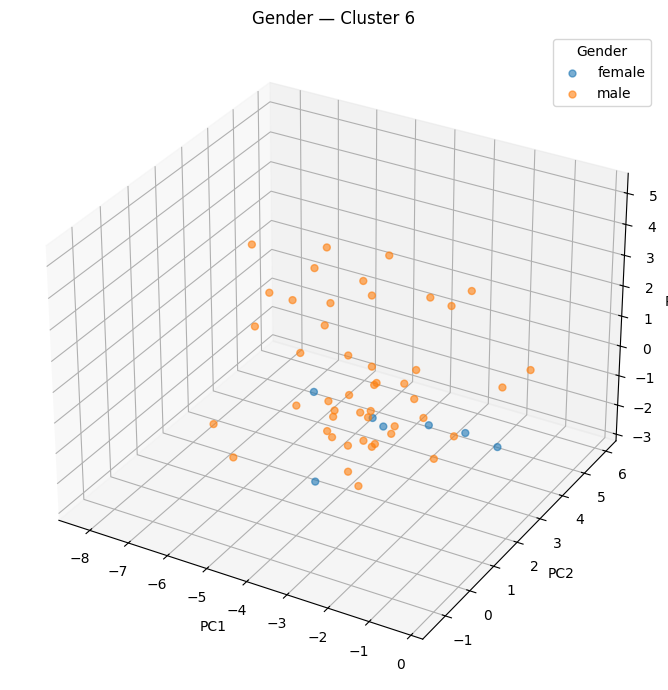

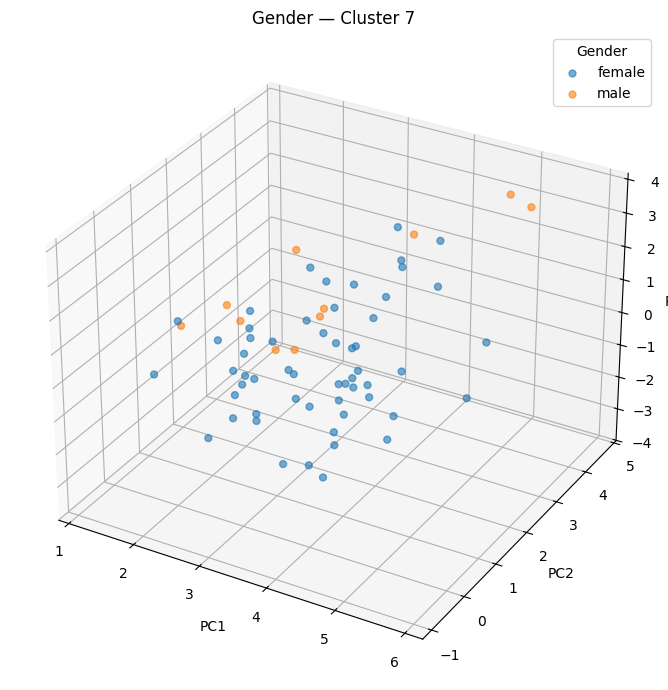

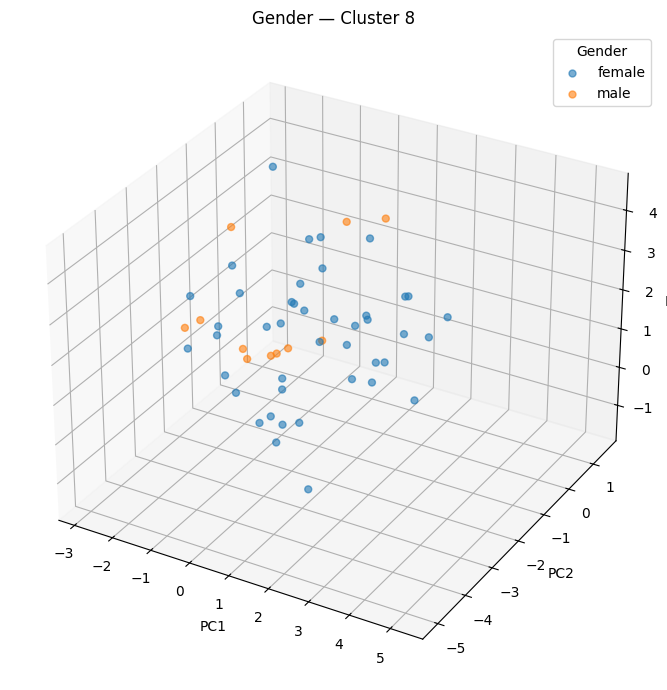

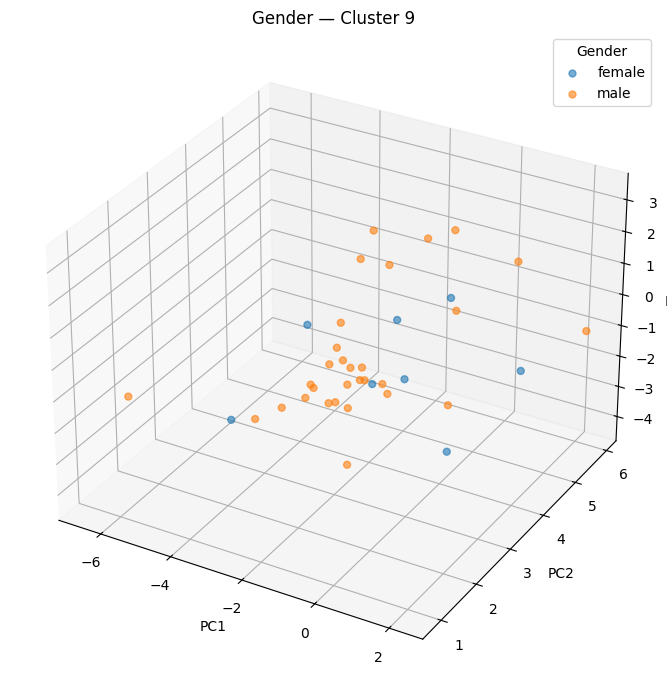

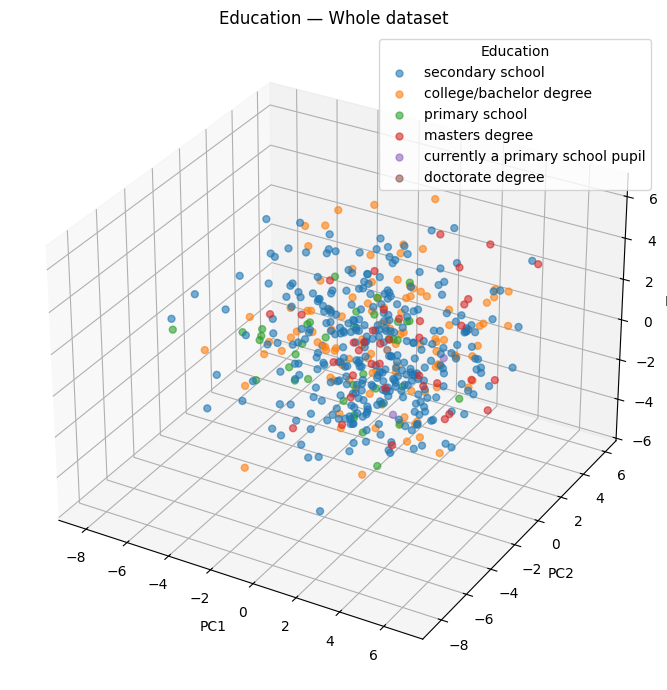

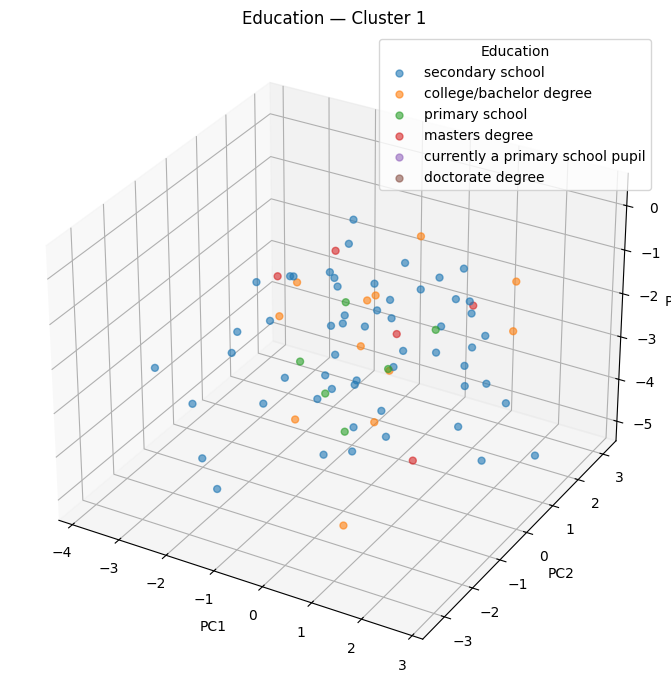

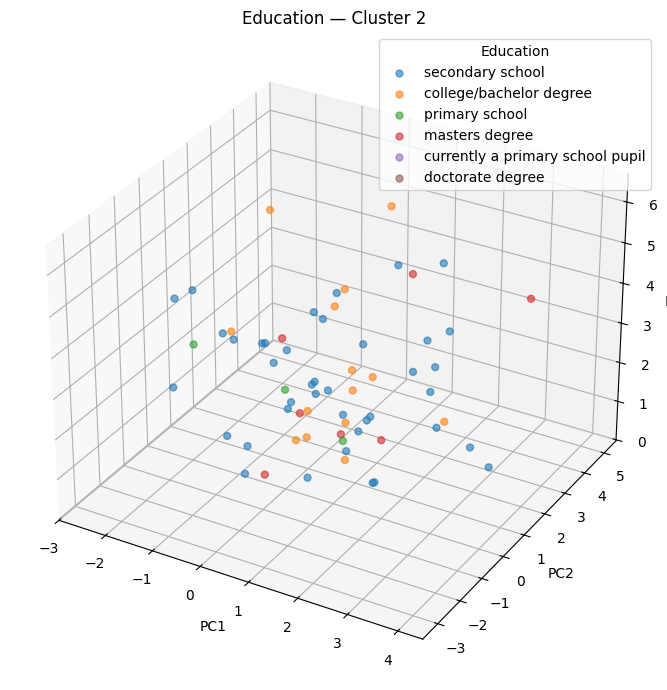

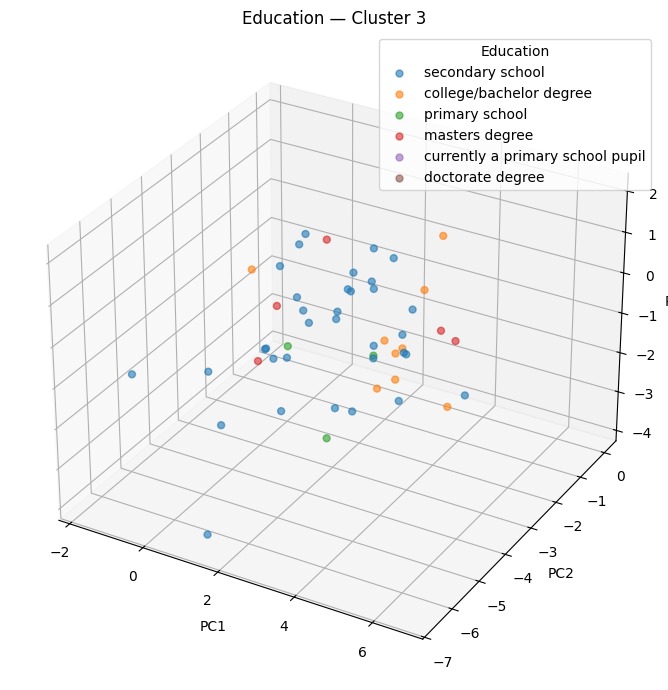

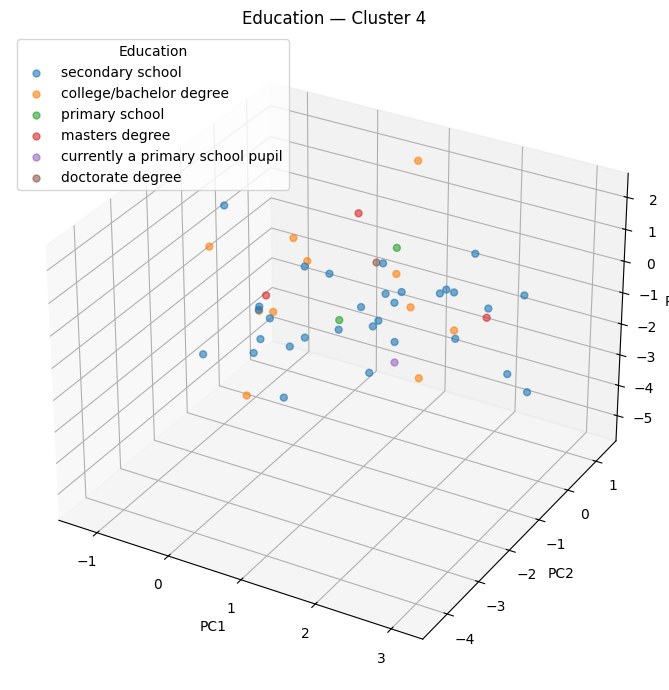

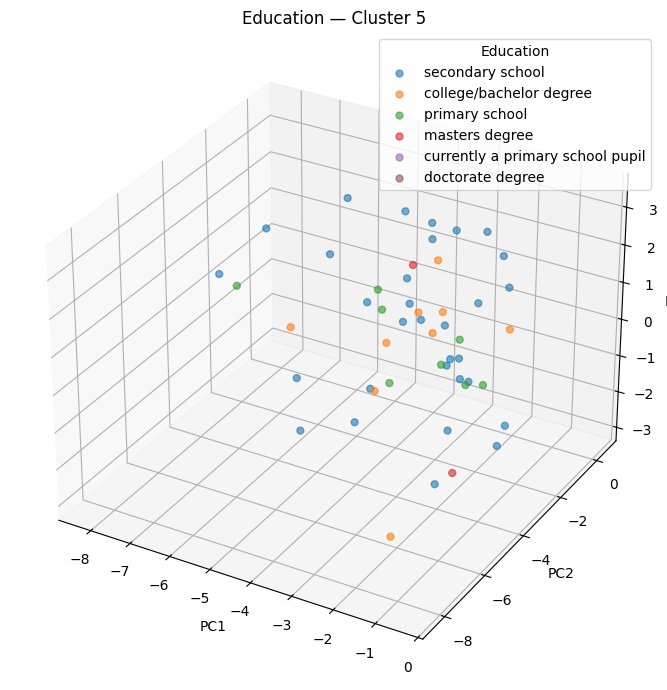

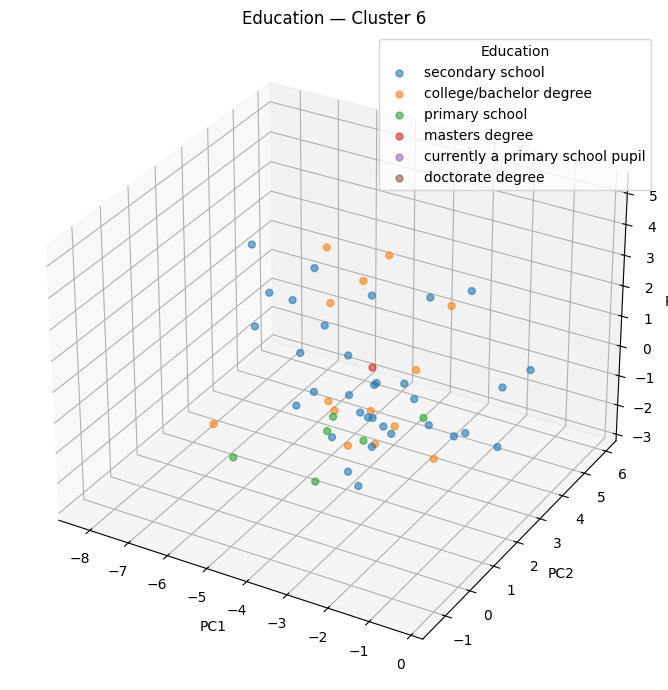

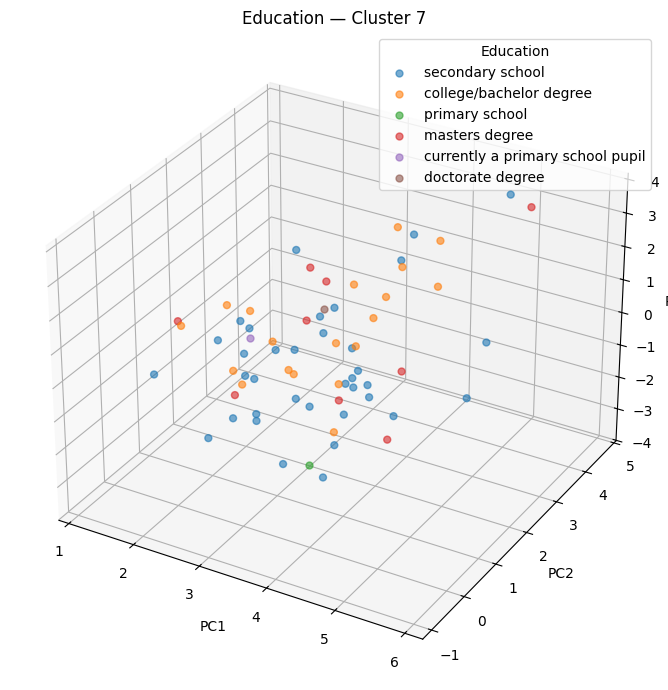

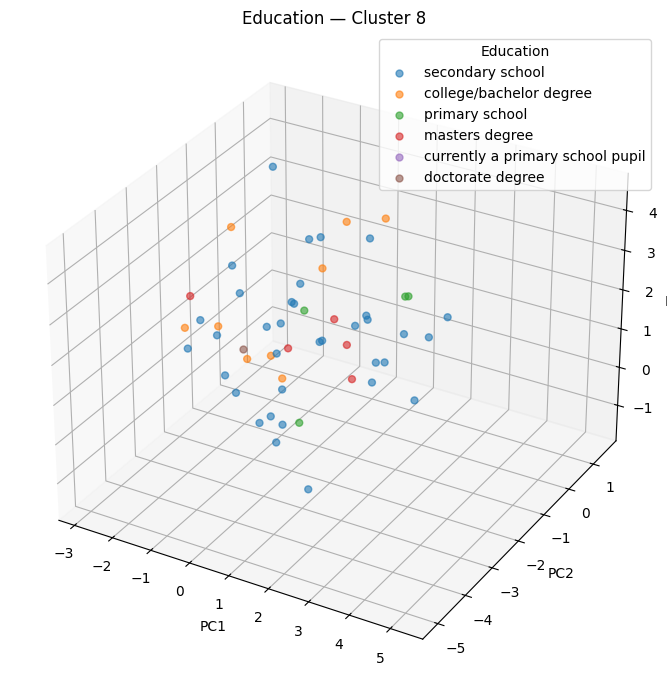

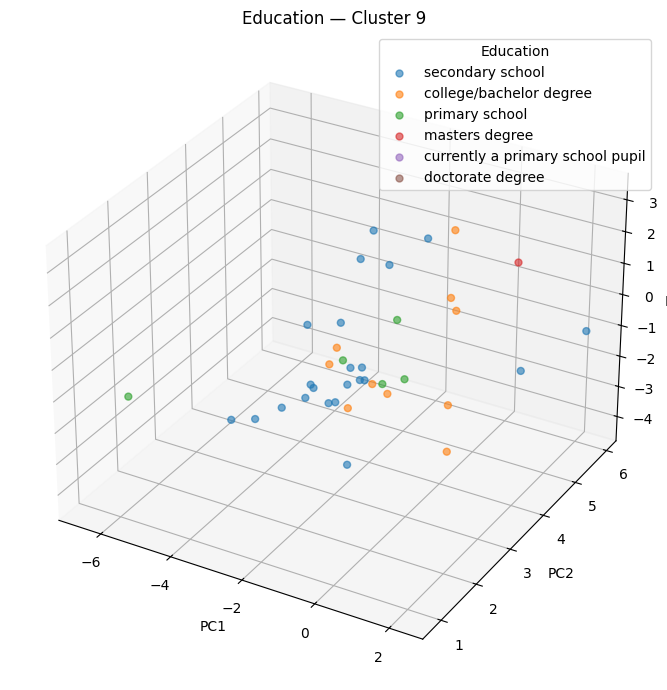

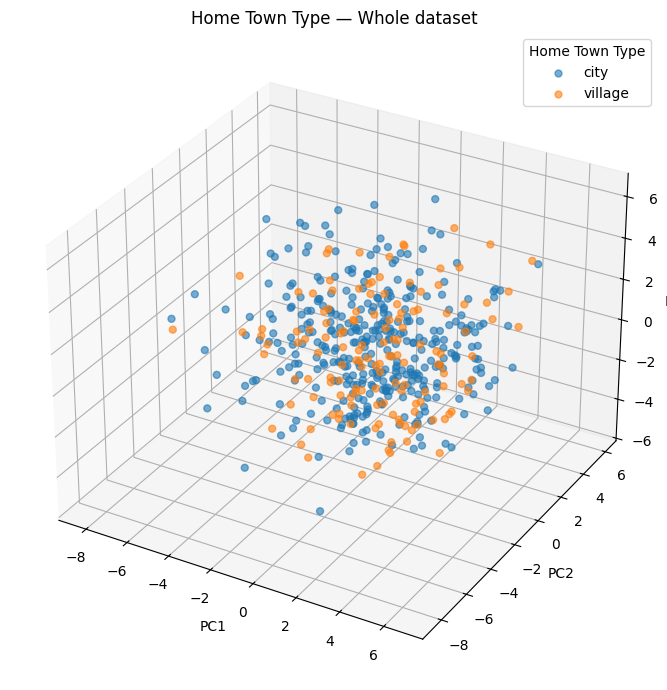

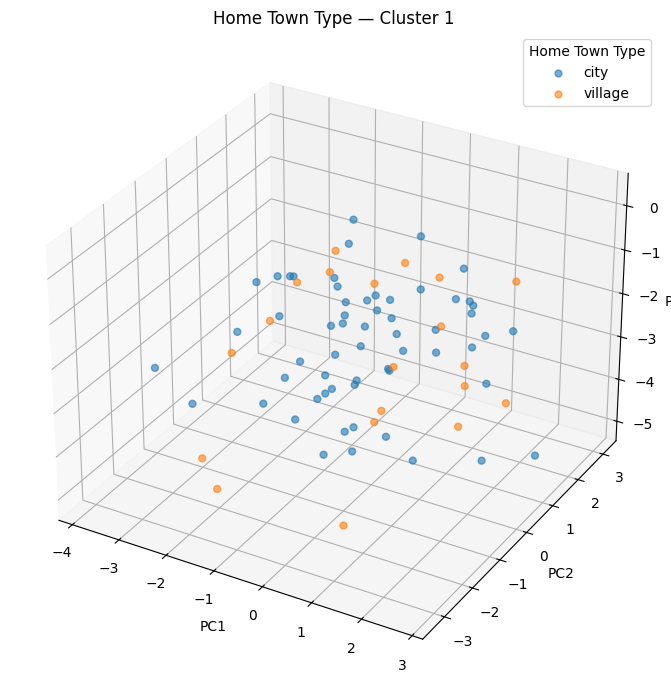

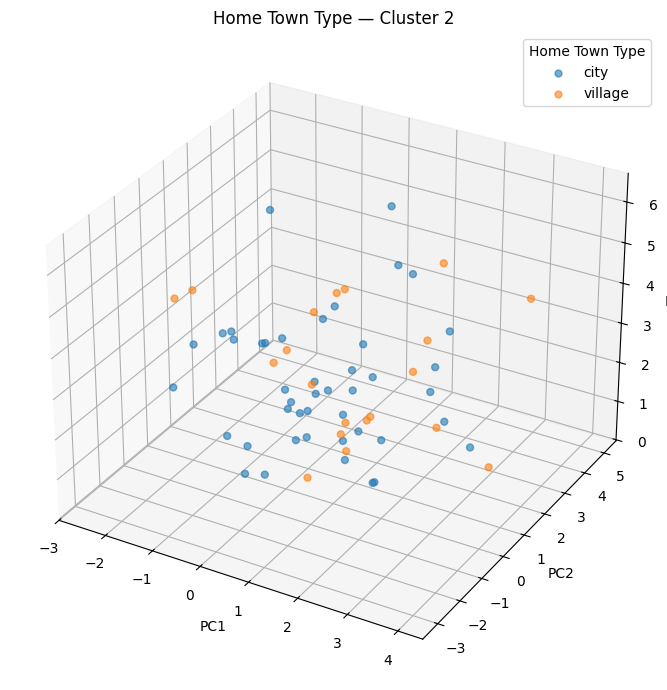

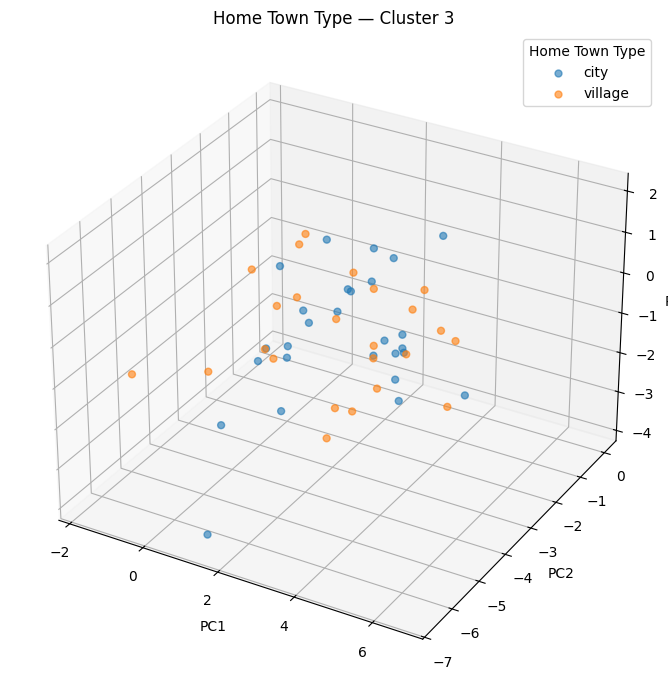

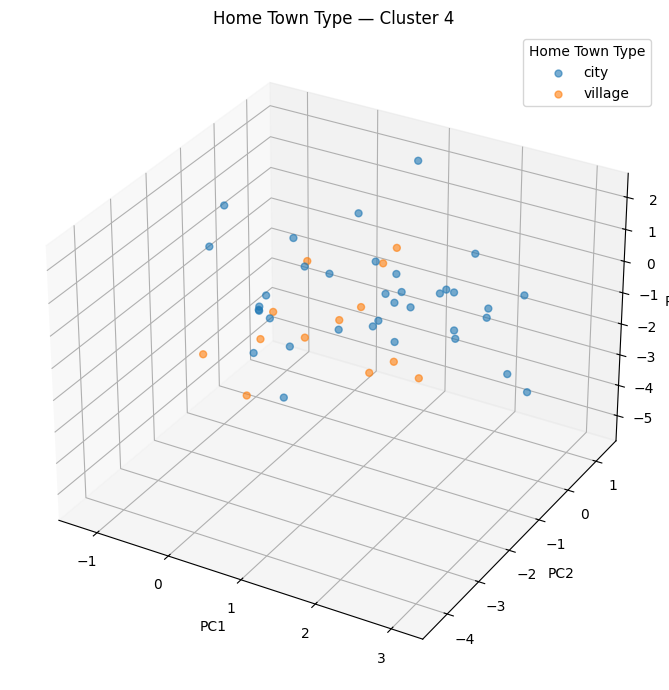

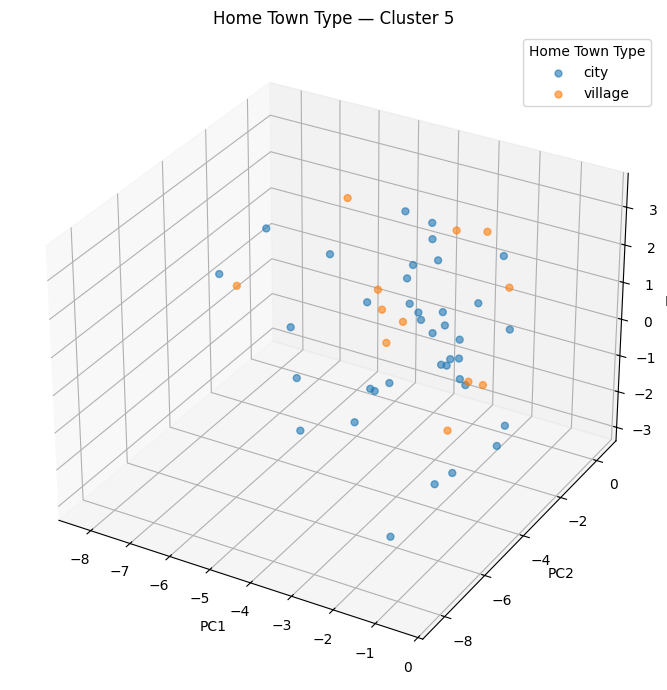

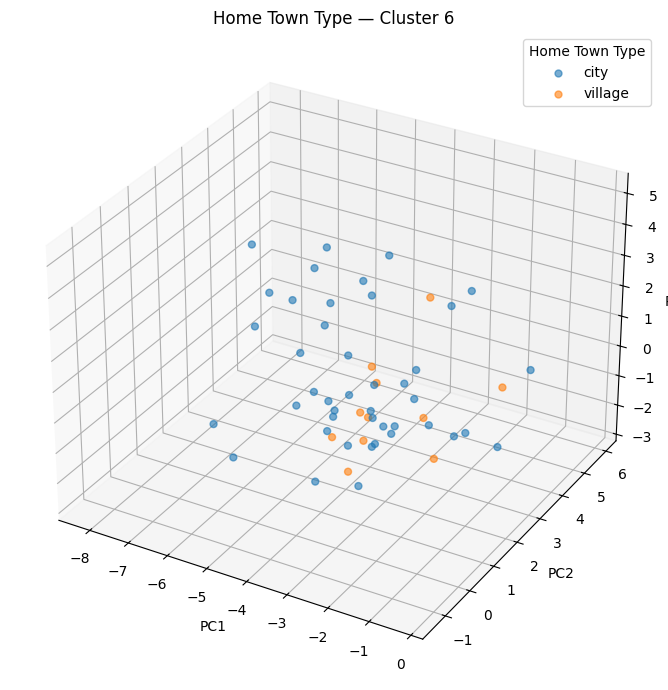

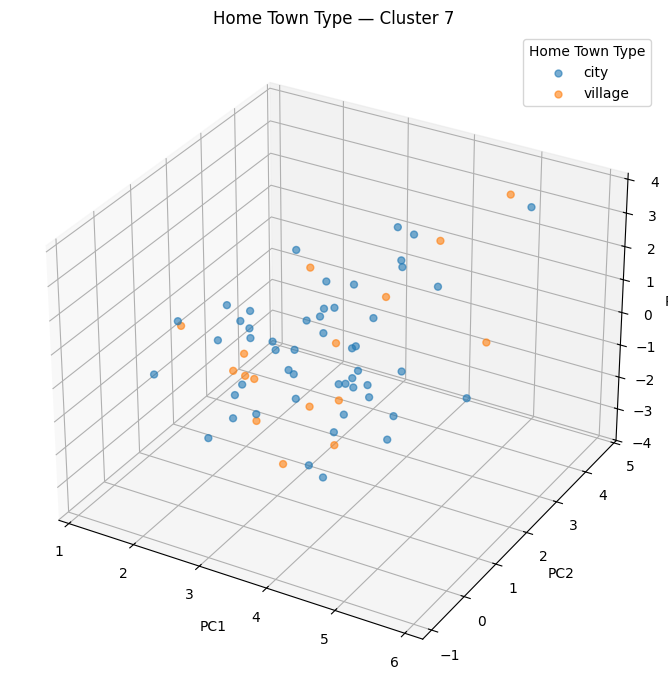

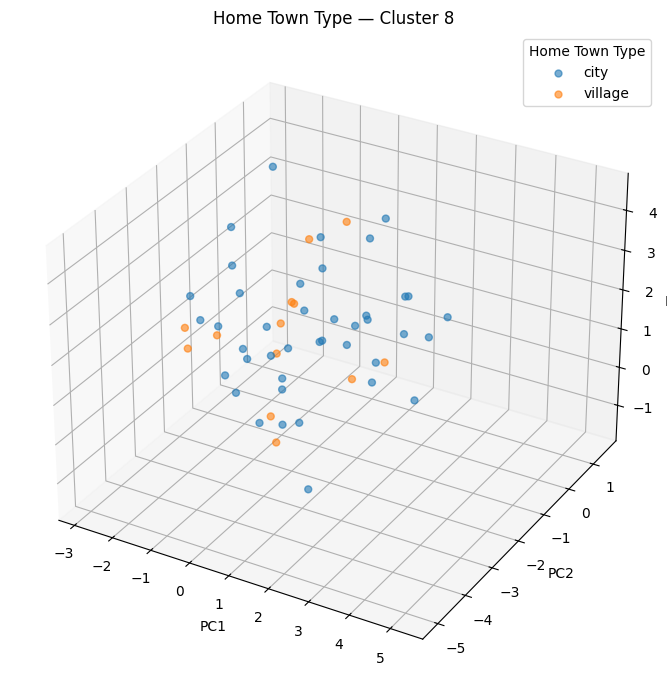

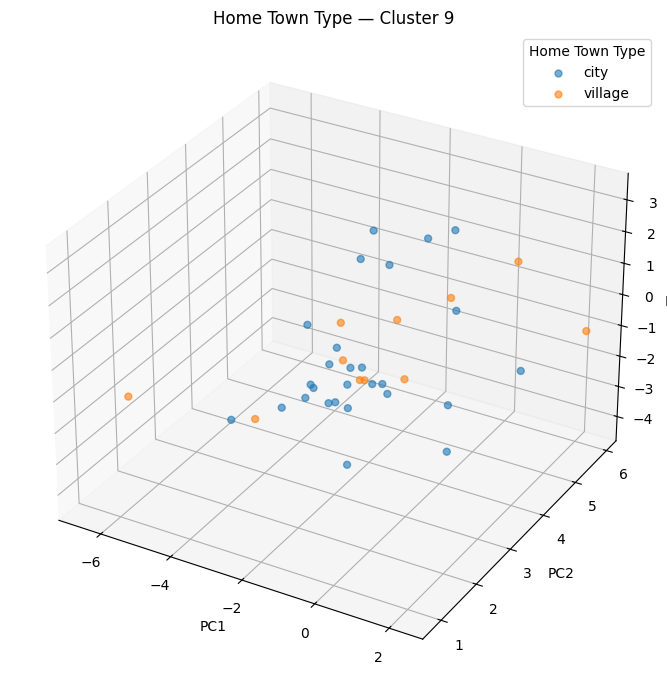

In [93]:
# 5.1. Select labels for external evaluation
selected_labels = ['Gender', 'Education', 'Home Town Type']

selected_labels_df = responses_lb.loc[
    responses_ft_pca.index, selected_labels
].copy()

# **************************************************************************************************************
# 5.2. Compare label distributions across clusters and the whole dataset
# Her kümede hangi kategoriden ne kadar var?

evaluation_df = responses_lb.loc[
    responses_ft_pca.index, selected_labels
].copy()

evaluation_df['Cluster'] = cluster_labels + 1

for label in selected_labels:
    # Include missing values as a separate category, if present
    label_values = evaluation_df[label].fillna('Missing')

    # Overall distribution (%)
    overall_distribution = (
        label_values.value_counts(normalize=True) * 100
    )

    # Distribution within each cluster (%)
    cluster_distribution = pd.crosstab(
        evaluation_df['Cluster'],
        label_values,
        normalize='index'
    ) * 100

    cluster_distribution.index = [
        f'Cluster {cluster}'
        for cluster in cluster_distribution.index
    ]

    # Combine overall and cluster distributions
    distribution_table = pd.concat([
        overall_distribution.to_frame().T.rename(
            index={overall_distribution.name: 'Whole dataset'}
        ),
        cluster_distribution
    ]).fillna(0)

    # Ensure a consistent name for the first row
    distribution_table.index = [
        'Whole dataset', *cluster_distribution.index
    ]

    ax = distribution_table.plot(
        kind='bar',
        figsize=(12, 6),
        width=0.8,
        rot=0
    )

    ax.set_title(f'{label} Distribution: Whole Dataset and Clusters')
    ax.set_xlabel('Group')
    ax.set_ylabel('Percentage within group (%)')
    ax.set_ylim(0, 100)
    ax.legend(title=label, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    display(distribution_table.round(2))
    
# **************************************************************************************************************

# 5.3. Score graphs colored by label values
# Bu kategoriler PCA uzayında nerelerde bulunuyor?

for label in selected_labels:
    values = responses_lb.loc[responses_ft_pca.index, label].fillna('Missing')
    categories = values.unique()

    for cluster in [None] + list(np.unique(cluster_labels)):
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')

        for i, category in enumerate(categories):
            mask = (values == category).to_numpy()
            if cluster is not None:
                mask &= cluster_labels == cluster

            points = responses_ft_pca.loc[mask]
            ax.scatter(
                *points.iloc[:, :3].to_numpy().T,
                color=plt.get_cmap('tab10')(i),
                label=str(category), s=25, alpha=0.6
            )

        ax.set(
            xlabel=pc_interpretation_names[0],
            ylabel=pc_interpretation_names[1],
            zlabel=pc_interpretation_names[2],
            title=f'{label} — ' + (
                'Whole dataset' if cluster is None
                else f'Cluster {cluster + 1}'
            )
        )
        ax.legend(title=label)
        plt.tight_layout()
        plt.show()


#### For each selected label, comment the results observed in the visualizations (max 100 words per label):

...

## Exercise 6. Cluster Internal Evaluations

In this exercise, you have to do the following operations:
1. For each cluster, measure the corresponding average silhouette score
1. Visualize the silhouette of the clusters and the general one of the clustering and compare them


#### Write the code for computing the silhouette scores and for visualizing them:

Cluster 1: 0.2058
Cluster 2: 0.1403
Cluster 3: 0.1577
Cluster 4: 0.1848
Cluster 5: 0.1472
Cluster 6: 0.1242
Cluster 7: 0.1810
Cluster 8: 0.1493
Cluster 9: 0.2029

Overall silhouette score: 0.1666


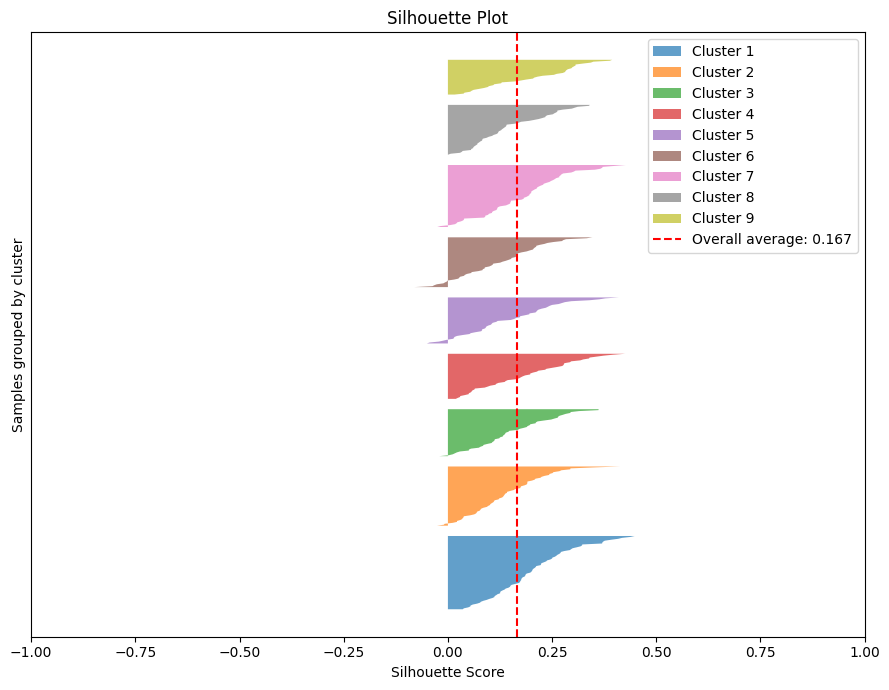

In [94]:
# 6.1. Compute the average silhouette score for each cluster

#numpy array that stores the siluet score for each person
#cluster_labels = 1,2,3,4
sample_scores = silhouette_samples(responses_ft_pca, cluster_labels) 

for cluster in np.unique(cluster_labels):
    mean_score = sample_scores[cluster_labels == cluster].mean()  #mean score for each cluster 
    print(f'Cluster {cluster + 1}: {mean_score:.4f}')

print(f'\nOverall silhouette score: {sample_scores.mean():.4f}')

# ****************************************************************************************************************

# 6.2. Visualize cluster silhouettes and the overall average

plt.figure(figsize=(9, 7))
y_lower = 10

for cluster in np.unique(cluster_labels):
    scores = np.sort(sample_scores[cluster_labels == cluster])
    y_upper = y_lower + len(scores)

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, scores,
        alpha=0.7,
        label=f'Cluster {cluster + 1}'
    )

    y_lower = y_upper + 10

plt.axvline(
    sample_scores.mean(),
    color='red',
    linestyle='--',
    label=f'Overall average: {sample_scores.mean():.3f}'
)

plt.xlabel('Silhouette Score')
plt.ylabel('Samples grouped by cluster')
plt.title('Silhouette Plot')
plt.yticks([])
plt.xlim(-1, 1)
plt.legend()
plt.tight_layout()
plt.show()

#### Comment the results, also considering the results observed previously (e.g., score graphs, centroids, etc. - max 150 words):

...